<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.

- **Group member 1:** Khushi Singh, 416164, khushi.singh@epfl.ch
- **Group member 2:** Ioana Jianu, 361831, ioana.jianu@epfl.ch
- **Group member 3 (if applicable):** Filippo Tognina, SCIPER number, email address  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

## 0.5 Provided data

All main data are stored in `/shared/NX-414/data/`.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

Dataset 1:             
    - Modality: fMRI data                   
    - Number of stimuli: 8302-9000, subject dependent because each subject saw different stimuli             
    - Shape of neural response: (number of stimuli, number of features/voxels)                  
    - Contains 8 subjects and 28 ROIs.              
    - Structure: Noise ceiling full and ROIwise, ROI labels, ROI labels noise ceiling, test and train neural data and stimulus ids for each subject.              
                            
Dataset 2:                                 
    - Modality: EEG data.                
    - Number of stimuli: 16540            
    - Shape of neural response: (number of stimuli, number of channels, number of timepoints)            
    - Contains 10 subjects, 7ROIs, 63 channels and 80 timepoints.          
    - Structure: Noise ceilings, and ROI-wise neural data and noise ceilings for train and test data for each subject.          
                          
Dataset 3:             
    - Modality: electrophysiology data.            
    - Number of stimuli: 22348                    
    - Shape of neural response: (number of stimuli, number of channels)           
    - Contains 2 subjects and 3 ROIs.                    
    - Structure: Noise ceilings and test and train neural data for each monkey.                           
                
Feature Set 1:             
    - Model id: adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0               
    - Number of layers: 10             
    - Number of stimuli:                      
        - NSD dataset: 73000                   
        - Things dataset: 26107               
    - Shape of each layer:                  
        - NSD dataset: (73000, 30000)                           
        - Things dataset: (26107, 30000)               
                    
Feature Set 2:                
    - Model id: Qwen3-VL-2B-Instruct            
    - Number of layers: 10             
    - Number of stimuli:         
        - NSD dataset: 73000                                       
        - Things dataset: 26107                           
    - Shape of each layer:               
        - NSD dataset: (73000, 30000)                     
        - Things dataset: (26107, 30000)    

The fMRI dataset is the most structurally complex as it has the largest number of groups and regions of interest and all subjects see different stimuli.

In [1]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch

In [3]:
#File paths
file_dir = '/shared/NX-414/data/'
filename_fMRI = 'nsd_func1pt8mm_individualROIs.h5'
filename_EEG = 'things_eeg2.h5'
filename_ephys = 'tvsd.h5'

model_dir = '/shared/NX-414/extracted_features/'
modelA = 'adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0'
modelB = 'Qwen3-VL-2B-Instruct'

# Utility Functions

# 1. To inspect h5 files
def inspect_h5(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} | Shape: {obj.shape} | Type: {obj.dtype}")
    elif isinstance(obj, h5py.Group):
        print(f"Group: {name}")


In [4]:
#inspect fMRI data
filepath_fMRI = f"{file_dir}{filename_fMRI}"

with h5py.File(filepath_fMRI, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print(f"Inspecting structure of: {filename_fMRI}\n" + "-"*40)
    f.visititems(inspect_h5)

--- Root Attributes ---
ROI_mapping: {"early": ["early"], "midventral": ["midventral"], "midlateral": ["midlateral"], "midparietal": ["midparietal"], "ventral": ["ventral"], "lateral": ["lateral"], "parietal": ["parietal"], "V1v": ["V1v"], "V1d": ["V1d"], "V2v": ["V2v"], "V2d": ["V2d"], "V3v": ["V3v"], "V3d": ["V3d"], "hV4": ["hV4"], "nsdgeneral": ["nsdgeneral"], "OWFA": ["OWFA"], "VWFA-1": ["VWFA-1"], "VWFA-2": ["VWFA-2"], "OPA": ["OPA"], "PPA": ["PPA"], "RSC": ["RSC"], "OFA": ["OFA"], "FFA-1": ["FFA-1"], "FFA-2": ["FFA-2"], "EBA": ["EBA"], "FBA-1": ["FBA-1"], "FBA-2": ["FBA-2"], "whole_brain": ["whole_brain"]}
beta_type: betas_fithrf_GLMdenoise_RR
data_space: func1pt8mm
dtype: float32
last_args: {"subject": "8", "data_space": "func1pt8mm", "beta_type": "betas_fithrf_GLMdenoise_RR", "ds_dir": "/mnt/scratch/akgokce/datasets/neural/nsd", "stim_csv_path": "/mnt/scratch/akgokce/brain/repos/data-driven-alignment/extract_n_eval/data/nsd_stim_mapping.csv", "roi_mapping": "individual", "nc_th

In [5]:
#inspect EEG data
filepath_EEG = f"{file_dir}{filename_EEG}"

with h5py.File(filepath_EEG, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print(f"Inspecting structure of: {filename_EEG}\n" + "-"*40)
    f.visititems(inspect_h5)

--- Root Attributes ---
channels: ['Fp1' 'F3' 'F7' 'FT9' 'FC5' 'FC1' 'C3' 'T7' 'TP9' 'CP5' 'CP1' 'Pz' 'P3'
 'P7' 'O1' 'Oz' 'O2' 'P4' 'P8' 'TP10' 'CP6' 'CP2' 'Cz' 'C4' 'T8' 'FT10'
 'FC6' 'FC2' 'F4' 'F8' 'Fp2' 'AF7' 'AF3' 'AFz' 'F1' 'F5' 'FT7' 'FC3' 'FCz'
 'C1' 'C5' 'TP7' 'CP3' 'P1' 'P5' 'PO7' 'PO3' 'POz' 'PO4' 'PO8' 'P6' 'P2'
 'CPz' 'CP4' 'TP8' 'C6' 'C2' 'FC4' 'FT8' 'F6' 'F2' 'AF4' 'AF8']
max_nc: 100
metadata: {
  "desc": "\n    The neural data is from the THINGS EEG 2, recorded from 10 humans.\n    All neural data is averaged across trials for each image.\n    The neural data is concatenated across subjects and channels.\n    "
}
rois: ['occipital' 'parietal' 'temporal' 'frontal' 'central'
 'occipital_parietal' 'whole_brain']
splits: ['train' 'test']
subjects: ['sub-01' 'sub-02' 'sub-03' 'sub-04' 'sub-05' 'sub-06' 'sub-07' 'sub-08'
 'sub-09' 'sub-10']
time_points: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0

In [6]:
#inspect ephys data
filepath_ephys = f"{file_dir}{filename_ephys}"

with h5py.File(filepath_ephys, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print(f"Inspecting structure of: {filename_ephys}\n" + "-"*40)
    f.visititems(inspect_h5)

--- Root Attributes ---
max_nc: 100
metadata: {
  "reliability": 0.1,
  "channel2region": {
    "monkeyN": {
      "V1": [
        0,
        511
      ],
      "V4": [
        512,
        767
      ],
      "IT": [
        768,
        1023
      ]
    },
    "monkeyF": {
      "V1": [
        0,
        511
      ],
      "V4": [
        832,
        1023
      ],
      "IT": [
        512,
        831
      ]
    }
  },
  "desc": "\n    The neural data is from the THINGS dataset, recorded from two monkeys (monkeyN and monkeyF).\n    The neural data is recorded from V1, V4, and IT regions.\n    The dataset includes both training and test splits.\n    Channels with reliability less than 0.1 are excluded.\n    "
}
rois: ['V1' 'V4' 'IT']
splits: ['train' 'test']
subjects: ['monkeyN' 'monkeyF']
Inspecting structure of: tvsd.h5
----------------------------------------
Group: noise_ceilings
Group: noise_ceilings/monkeyF
Dataset: noise_ceilings/monkeyF/IT | Shape: (241,) | Type: float64
Da

In [7]:
# inspect Model A NSD
filepath_mA_nsd = f"{model_dir}{modelA}{'/nsd_stimuli.h5'}"

with h5py.File(filepath_mA_nsd, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print('Inspecting structure')
    f.visititems(inspect_h5)

--- Root Attributes ---
backbone_source: spvvs
config_json: {"model_id": "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0", "backbone_source": "spvvs", "layer_config": "None", "lora_config": "None", "backbone_checkpoint": null, "target_feature_layers": null, "committed_extraction_layers": "nx414_project/helpers/committed_extraction_layers.json", "layer_commitments_model_id": "resnet152_imagenet_full", "data_root": "/mnt/scratch/akgokce/datasets/neural/nsd/nsd_stimuli.hdf5", "dataset_type": "h5", "output_dir": "outputs/features_batched_committed/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/nsd_stimuli", "batch_size": 256, "num_workers": 8, "flatten_features": true, "max_feature_dim": 30000, "overwrite": false, "dtype": "float16", "prompt": null, "seed": 42, "projector_backend": "pytorch", "projector_type": "gaussian", "projector_cache": "cache/projectors/", "use_cached_projectors": true, "append_features": false, "random_seed": 42, "device": "cuda"}
model_

In [8]:
# inspect Model A things
filepath_mA_things = f"{model_dir}{modelA}{'/things_stimuli.h5'}"

with h5py.File(filepath_mA_things, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print('Inspecting structure')
    f.visititems(inspect_h5)

--- Root Attributes ---
backbone_source: spvvs
config_json: {"model_id": "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0", "backbone_source": "spvvs", "layer_config": "None", "lora_config": "None", "backbone_checkpoint": null, "target_feature_layers": null, "committed_extraction_layers": "nx414_project/helpers/committed_extraction_layers.json", "layer_commitments_model_id": "resnet152_imagenet_full", "data_root": "/mnt/scratch/akgokce/datasets/neural/things_raw/image_db/images/object_images", "dataset_type": "things", "output_dir": "outputs/features_batched_committed/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/object_images", "batch_size": 256, "num_workers": 8, "flatten_features": true, "max_feature_dim": 30000, "overwrite": false, "dtype": "float16", "prompt": null, "seed": 42, "projector_backend": "pytorch", "projector_type": "gaussian", "projector_cache": "cache/projectors/", "use_cached_projectors": true, "append_features": false, "random_seed": 42

In [9]:
# inspect Model B NSD
filepath_mB_nsd = f"{model_dir}{modelB}{'/nsd_stimuli.h5'}"

with h5py.File(filepath_mB_nsd, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print('Inspecting structure')
    f.visititems(inspect_h5)

--- Root Attributes ---
backbone_source: hf
config_json: {"model_id": "Qwen3-VL-2B-Instruct", "backbone_source": "hf", "layer_config": "None", "lora_config": "None", "backbone_checkpoint": null, "target_feature_layers": null, "committed_extraction_layers": "nx414_project/helpers/committed_extraction_layers.json", "layer_commitments_model_id": null, "data_root": "/mnt/scratch/akgokce/datasets/neural/nsd/nsd_stimuli.hdf5", "dataset_type": "h5", "output_dir": "outputs/features_batched_committed/Qwen3-VL-2B-Instruct/nsd_stimuli", "batch_size": 256, "num_workers": 8, "flatten_features": true, "max_feature_dim": 30000, "overwrite": true, "dtype": "float16", "prompt": null, "seed": 42, "projector_backend": "pytorch", "projector_type": "gaussian", "projector_cache": "cache/projectors/", "use_cached_projectors": true, "append_features": false, "random_seed": 42, "device": "cuda"}
model_id: Qwen3-VL-2B-Instruct
target_feature_layers: ["visual.blocks.2", "visual.blocks.6", "visual.blocks.10", "vi

In [10]:
# inspect Model B things
filepath_mB_things = f"{model_dir}{modelB}{'/things_stimuli.h5'}"

with h5py.File(filepath_mB_things, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print('Inspecting structure')
    f.visititems(inspect_h5)

--- Root Attributes ---
backbone_source: hf
config_json: {"model_id": "Qwen3-VL-2B-Instruct", "backbone_source": "hf", "layer_config": "None", "lora_config": "None", "backbone_checkpoint": null, "target_feature_layers": null, "committed_extraction_layers": "nx414_project/helpers/committed_extraction_layers.json", "layer_commitments_model_id": null, "data_root": "/mnt/scratch/akgokce/datasets/neural/things_raw/image_db/images/object_images", "dataset_type": "things", "output_dir": "outputs/features_batched_committed/Qwen3-VL-2B-Instruct/object_images", "batch_size": 256, "num_workers": 8, "flatten_features": true, "max_feature_dim": 30000, "overwrite": true, "dtype": "float16", "prompt": null, "seed": 42, "projector_backend": "pytorch", "projector_type": "gaussian", "projector_cache": "cache/projectors/", "use_cached_projectors": true, "append_features": false, "random_seed": 42, "device": "cuda"}
model_id: Qwen3-VL-2B-Instruct
target_feature_layers: ["visual.blocks.2", "visual.blocks.6

In [11]:
filepath_mA_nsd = '/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/nsd_stimuli.h5'
filepath_mA_things = '/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/things_stimuli.h5'
filepath_mB_nsd = '/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/nsd_stimuli.h5'
filepath_mB_things = '/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/things_stimuli.h5'

In [12]:
neural_path = '/shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5'
model_path = '/shared/NX-414/extracted_features/Qwen3-VL-2B-Instruct/nsd_stimuli.h5'

with h5py.File(neural_path, 'r') as f_brain, h5py.File(model_path, 'r') as f_model:
    subj_train_ids = f_brain['train/stimulus_ids/subj01'][:]
    model_ids = f_model['ids'][:]
    
    id_to_idx = {id_val: i for i, id_val in enumerate(model_ids)}
    target_indices = np.array([id_to_idx[sid] for sid in subj_train_ids])

    sort_order = np.argsort(target_indices)
    sorted_idx = target_indices[sort_order]

    raw_features = f_model['features/visual-blocks-10'][sorted_idx, :]
    
    rev_order = np.argsort(sort_order)
    subj_features = raw_features[rev_order, :]

print(f"Features for Subject 01 loaded. Shape: {subj_features.shape}")

# To check stimulus matching:
print(f"nth ID seen by Subj01: {subj_train_ids[3780]}")
print(f"nth ID at matching feature row: {model_ids[target_indices[3780]]}")

Features for Subject 01 loaded. Shape: (9000, 30000)
nth ID seen by Subj01: 31221
nth ID at matching feature row: 31221


---

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

In [13]:
# TODO: inspect TVSD
# TODO: inspect EEG2
# TODO: inspect NSD
# TODO: summarize axis meaning

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

|Metric | Dataset 1 | Dataset 2 | Dataset 3 |
| --- | --- | --- | --- |
| Modality | fMRI | EEG | Electrophysiology |
| What is being measured? | BOLD response | Averaged activity of a group of neurons in a specific area | Activity of a single neuron |
| Number of subjects | 8 | 10 | 2 |
| Species of subjects | Human | Human | Monkey |
| Stimuli Dataset | NSD | Things | Things |
| Number of Stimuli | 8302-9000 (subject dependent) | 16540 | 22348 |
| Number of ROIs | 28 | 7 | 3 |
| Number of channels | - | 63 | 139-462 (varies with monkey and region) |
| Number of timepoints | - | 80 | - |

All datasets contain noise ceilings and neural data split into train and test sets for each subject.              


---

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

Upon averaging the whole brain EEG recording for all subjects, we see that Occipital and Parietal channels are the most reliable across subjects.                        
![Average All Subjects Whole Brain EEG Noise Ceiling](Noise_Ceiling.png "Average All Subjects Whole Brain EEG Noise Ceiling")       
We observe clear evoked structure in the occipital-parietal ROI for all subjects, however channels have increased activity at different timepoints for different subjects, suggesting inter-subject variability in visual processing times.              
![Evoked Structure Occipital-Parietal ROI Subject 01](EvokedEEG-Sub01.png "Evoked Structure Occipital-Parietal ROI Subject 01")            
![Evoked Structure Occipital-Parietal ROI Subject 02](EvokedEEG-Sub10.png "Evoked Structure Occipital-Parietal ROI Subject 02")         

In [14]:
# TODO: load one EEG subject / ROI
# TODO: plot example traces
# TODO: plot channel x time heatmap
# TODO: visualize provided EEG noise ceilings

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1622/3331506670.py:25: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Amplitude ($\mu$V)')


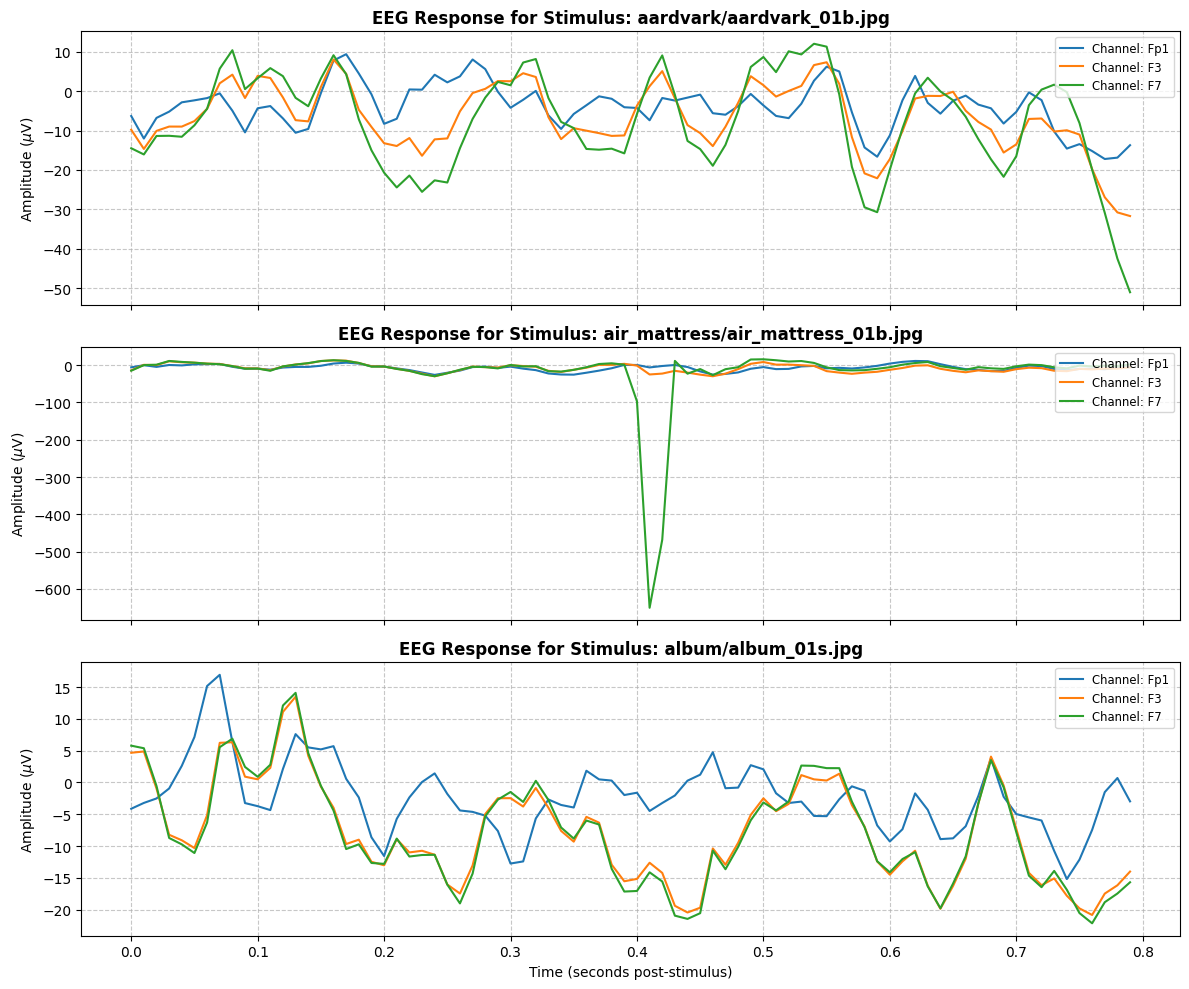

In [15]:
with h5py.File(filepath_EEG, 'r') as f:
    
    channels = f.attrs['channels']
    time_points = f.attrs['time_points']
    stimulus_ids = f['train/stimulus_ids'][:]
    neural_data = f['train/neural_data/sub-01/occipital_parietal']

    stim_indices = [0, 50, 100] 
    target_channels = ['Fp1', 'F3', 'F7']
    chan_indices = [np.where(channels == ch)[0][0] for ch in target_channels]
    
    fig, axes = plt.subplots(len(stim_indices), 1, figsize=(12, 10), sharex=True)
    for i, stim_idx in enumerate(stim_indices):
        ax = axes[i]
        stim_id = stimulus_ids[stim_idx]
        if isinstance(stim_id, bytes):
            stim_id = stim_id.decode('utf-8')
            
        for chan_idx in chan_indices:
            chan_name = channels[chan_idx]
            trace = neural_data[stim_idx, chan_idx, :]
            ax.plot(time_points, trace, label=f'Channel: {chan_name}', linewidth=1.5)
        
        ax.set_title(f'EEG Response for Stimulus: {stim_id}', fontweight='bold')
        ax.set_ylabel('Amplitude ($\mu$V)')
        ax.legend(loc='upper right', frameon=True, fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.7)
        
    axes[-1].set_xlabel('Time (seconds post-stimulus)')
    plt.tight_layout()
    plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1622/3462830499.py:12: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label('Amplitude ($\mu$V)', rotation=270, labelpad=15)


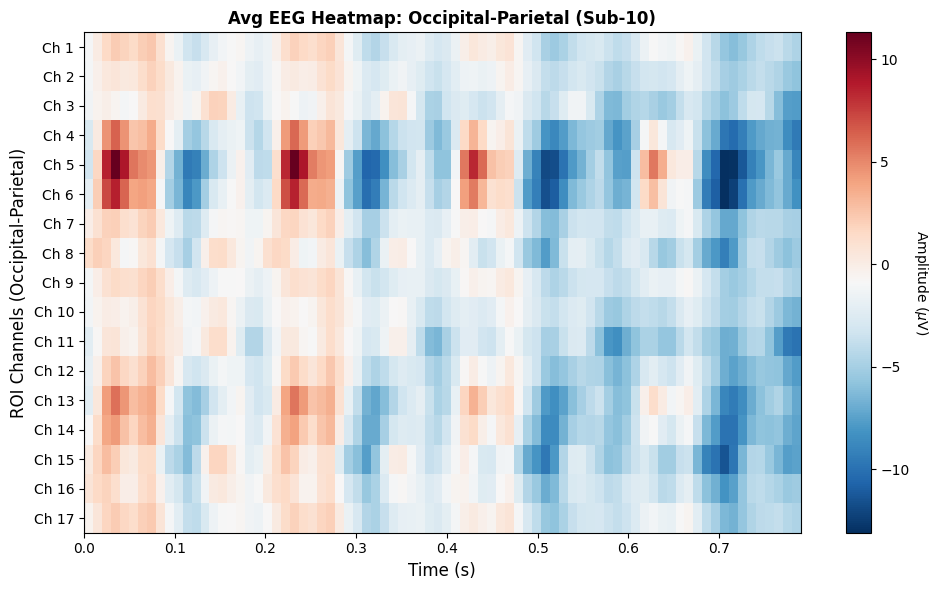

In [16]:
with h5py.File(filepath_EEG, 'r') as f:
    all_channels = f.attrs['channels']
    time_points = f.attrs['time_points']
    avg_data = np.mean(f['train/neural_data/sub-10/occipital_parietal'][:], axis=0)
    
    num_roi_channels = avg_data.shape[0]
    
    plt.figure(figsize=(10, 6))
    im = plt.imshow(avg_data, aspect='auto', cmap='RdBu_r', interpolation='none',
                    extent=[time_points[0], time_points[-1], num_roi_channels, 0])
    cbar = plt.colorbar(im)
    cbar.set_label('Amplitude ($\mu$V)', rotation=270, labelpad=15)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('ROI Channels (Occipital-Parietal)', fontsize=12)
    plt.title('Avg EEG Heatmap: Occipital-Parietal (Sub-10)', fontweight='bold')
    plt.yticks(np.arange(num_roi_channels) + 0.5, [f"Ch {i+1}" for i in range(num_roi_channels)])
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('EvokedEEG-Sub10')

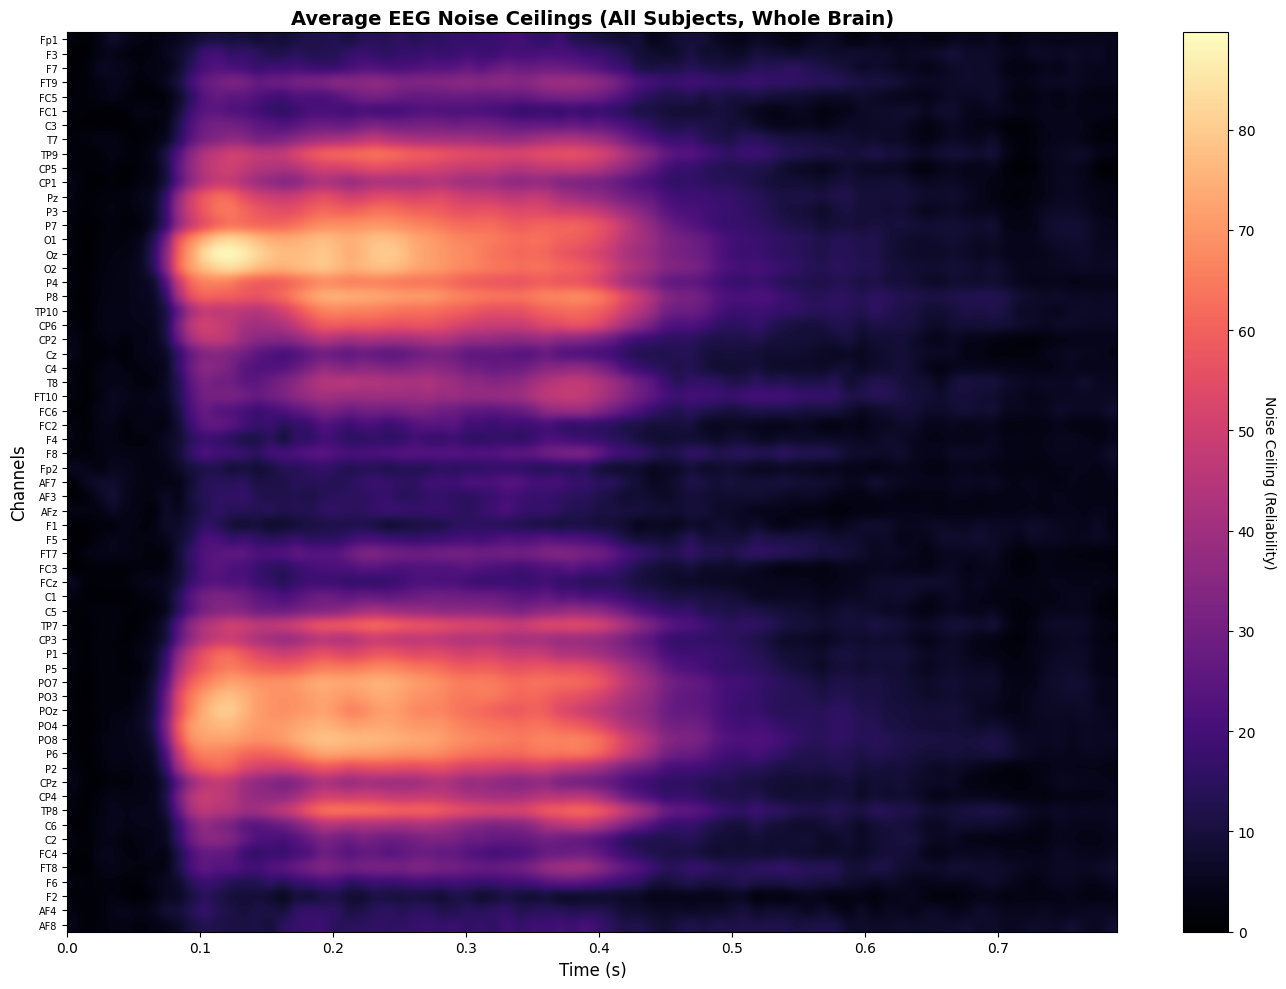

In [17]:
with h5py.File(filepath_EEG, 'r') as f:
    channels = f.attrs['channels']
    time_points = f.attrs['time_points']
    subjects = f.attrs['subjects']
    
    nc_list = []
    for sub in subjects:
        sub_id = sub.decode('utf-8') if isinstance(sub, bytes) else sub
        dataset_path = f'noise_ceilings/{sub_id}/whole_brain'
        nc_list.append(f[dataset_path][:])
    
    avg_nc = np.mean(nc_list, axis=0)
    plt.figure(figsize=(14, 10))
    im = plt.imshow(avg_nc, aspect='auto', cmap='magma', interpolation='gaussian',
                    extent=[time_points[0], time_points[-1], len(channels), 0])
    cbar = plt.colorbar(im)
    cbar.set_label('Noise Ceiling (Reliability)', rotation=270, labelpad=15)
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Channels', fontsize=12)
    plt.title('Average EEG Noise Ceilings (All Subjects, Whole Brain)', fontweight='bold', fontsize=14)
    plt.yticks(np.arange(len(channels)) + 0.5, channels, fontsize=7)
    plt.tight_layout()
    plt.savefig('Noise_Ceiling')

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [18]:
# inspect repetitions file
file_path = '/shared/NX-414/data/things_eeg2-test_reps.h5'

with h5py.File(file_path, 'r') as f:
    print("--- Root Attributes ---")
    if f.attrs:
        for k, v in f.attrs.items():
            print(f"{k}: {v}")
    else:
        print("No attributes at root.")
    print(f"Inspecting structure of: {file_path}\n" + "-"*40)
    f.visititems(inspect_h5)

--- Root Attributes ---
channels: ['Fp1' 'F3' 'F7' 'FT9' 'FC5' 'FC1' 'C3' 'T7' 'TP9' 'CP5' 'CP1' 'Pz' 'P3'
 'P7' 'O1' 'Oz' 'O2' 'P4' 'P8' 'TP10' 'CP6' 'CP2' 'Cz' 'C4' 'T8' 'FT10'
 'FC6' 'FC2' 'F4' 'F8' 'Fp2' 'AF7' 'AF3' 'AFz' 'F1' 'F5' 'FT7' 'FC3' 'FCz'
 'C1' 'C5' 'TP7' 'CP3' 'P1' 'P5' 'PO7' 'PO3' 'POz' 'PO4' 'PO8' 'P6' 'P2'
 'CPz' 'CP4' 'TP8' 'C6' 'C2' 'FC4' 'FT8' 'F6' 'F2' 'AF4' 'AF8']
metadata: {
  "desc": "\n    The neural data is from the THINGS EEG 2, recorded from 10 humans.\n    Test repetitions are preserved.\n    "
}
rois: ['occipital' 'parietal' 'temporal' 'frontal' 'central'
 'occipital_parietal' 'whole_brain']
splits: ['test']
subjects: ['sub-01' 'sub-02' 'sub-03' 'sub-04' 'sub-05' 'sub-06' 'sub-07' 'sub-08'
 'sub-09' 'sub-10']
time_points: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.

In [19]:
def compute_ceiling_variance(responses: np.ndarray) -> np.ndarray:
    """
    Computes the variance-based noise ceiling (R^2 equivalent).
    Input Shape: (n_stimuli, n_channels, n_timepoints, n_reps)
    Returns Shape: (n_channels, n_timepoints)
    """
    n_stim, n_chan, n_time, n_reps = responses.shape
    mean_per_stimulus = np.mean(responses, axis=-1)
    var_total = np.var(mean_per_stimulus, axis=0, ddof=1)
    var_noise = np.mean(np.var(responses, axis=-1, ddof=1), axis=0)
    var_signal = var_total - (var_noise / n_reps)
    nc = np.divide(var_signal, var_total, out=np.zeros_like(var_signal), where=var_total != 0)
    return np.clip(nc, 0, 1)

In [20]:
def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False) -> np.ndarray:
    """
    Computes split-half reliability as a noise ceiling.
    Data shape: (n_stimuli, n_channels, n_timepoints, n_reps)
    Returns: (n_channels, n_timepoints)
    """
    n_stim, n_chan, n_time, n_reps = responses.shape
    
    n_use = n_reps - (n_reps % 2) if equalize_halves else n_reps
    half_size = n_use // 2
    fold_correlations = np.zeros((folds, n_chan, n_time))
    
    for f in range(folds):
        rng = np.random.default_rng(seed + f)
        indices = rng.permutation(n_reps)
        idx1, idx2 = indices[:half_size], indices[half_size:n_use]
        h1 = np.mean(responses[..., idx1], axis=-1)
        h2 = np.mean(responses[..., idx2], axis=-1)

        h1_m = h1 - np.mean(h1, axis=0, keepdims=True)
        h2_m = h2 - np.mean(h2, axis=0, keepdims=True)
        num = np.sum(h1_m * h2_m, axis=0)
        den = np.sqrt(np.sum(h1_m**2, axis=0) * np.sum(h2_m**2, axis=0))
        r = np.divide(num, den, out=np.zeros_like(num), where=den != 0)
        
        if spearman_brown:
            # Formula: (2 * r) / (1 + r)
            r = (2 * r) / np.maximum(1e-15, (1 + r))
            
        if clip_folds:
            r = np.clip(r, -1, 1)
            
        fold_correlations[f] = r
        
    return np.mean(fold_correlations, axis=0)

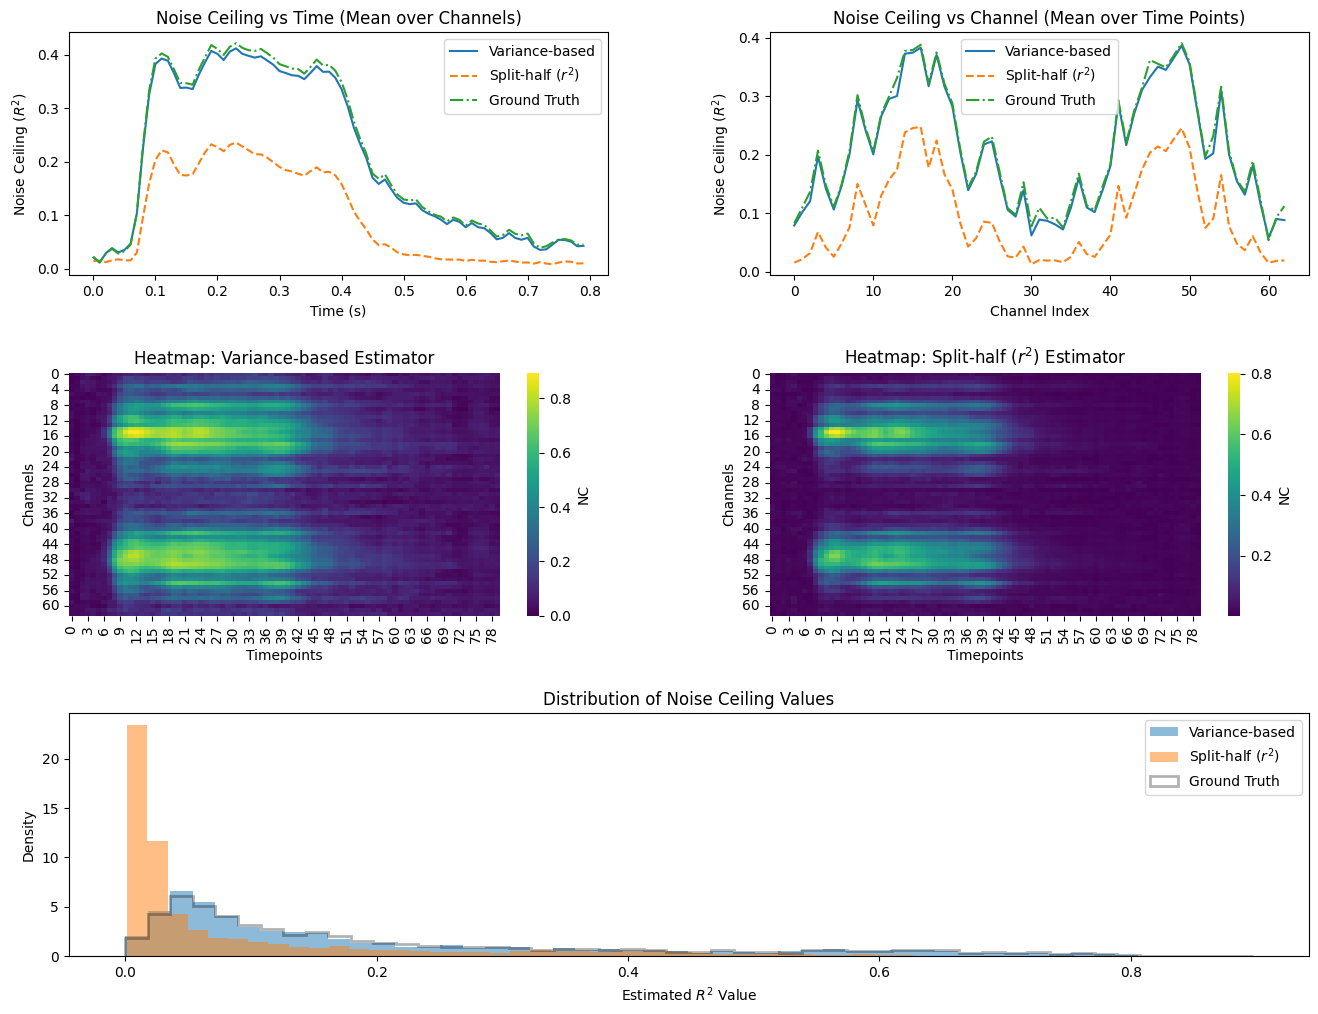

In [21]:
reps_data_path = '/shared/NX-414/data/things_eeg2-test_reps.h5'
nc_data_path = '/shared/NX-414/data/things_eeg2.h5'

all_nc_var, all_nc_sh, all_gt = [], [], []

with h5py.File(reps_data_path, 'r') as f_reps, h5py.File(nc_data_path, 'r') as f_nc:
    subject_keys = list(f_reps['test/neural_data'].keys())
    
    for sub in subject_keys:
        # Load and compute estimators
        data = f_reps[f'test/neural_data/{sub}/whole_brain'][:]
        all_nc_var.append(compute_ceiling_variance(data))
        all_nc_sh.append(compute_ceiling_splithalf(data, folds=20)**2) # Squaring here for R^2 comparison
        
        # Load Ground Truth 
        if f'noise_ceilings/{sub}/whole_brain' in f_nc:
            all_gt.append(f_nc[f'noise_ceilings/{sub}/whole_brain'][:]/100)
        else:
            print(f"Warning: {sub} missing in GT file.")

all_nc_var = np.array(all_nc_var)
all_nc_sh = np.array(all_nc_sh)
all_gt = np.array(all_gt)

# Average over subjects 
mean_var = np.mean(all_nc_var, axis=0)  # (Chan, Time)
mean_sh = np.mean(all_nc_sh, axis=0)    # (Chan, Time)
mean_gt = np.mean(all_gt, axis=0)        # (Chan, Time)

fig = plt.figure(figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1) Mean NC vs Time (Averaged over Subjects and Channels)
plt.subplot(3, 2, 1)
plt.plot(time_points, mean_var.mean(axis=0), label='Variance-based')
plt.plot(time_points, mean_sh.mean(axis=0), label='Split-half ($r^2$)', linestyle='--')
plt.plot(time_points, mean_gt.mean(axis=0), label='Ground Truth', linestyle='-.')
plt.title('Noise Ceiling vs Time (Mean over Channels)')
plt.xlabel('Time (s)'); plt.ylabel('Noise Ceiling ($R^2$)'); plt.legend(); #plt.savefig('NC_vs_Time'); plt.show()

# 2) Mean NC vs Channel (Averaged over Subjects and Timepoints)
plt.subplot(3, 2, 2)
chans = np.arange(mean_var.shape[0])
plt.plot(chans, mean_var.mean(axis=1), label='Variance-based')
plt.plot(chans, mean_sh.mean(axis=1), label='Split-half ($r^2$)', linestyle='--')
plt.plot(chans, mean_gt.mean(axis=1), label='Ground Truth', linestyle='-.')
plt.title('Noise Ceiling vs Channel (Mean over Time Points)')
plt.xlabel('Channel Index'); plt.ylabel('Noise Ceiling ($R^2$)'); plt.legend(); #plt.savefig('NC_vs_Channel'); plt.show()

# 3) Heatmaps (Channel x Time)
plt.subplot(3, 2, 3)
sns.heatmap(mean_var, cmap='viridis', cbar_kws={'label': 'NC'})
plt.title('Heatmap: Variance-based Estimator')
plt.xlabel('Timepoints'); plt.ylabel('Channels'); #plt.savefig('Heatmap_NC_Var'); plt.show()

plt.subplot(3, 2, 4)
sns.heatmap(mean_sh, cmap='viridis', cbar_kws={'label': 'NC'})
plt.title('Heatmap: Split-half ($r^2$) Estimator')
plt.xlabel('Timepoints'); plt.ylabel('Channels'); #plt.savefig('Heatmap_NC_SH'); plt.show()

# 4) Distribution Histogram
plt.subplot(3, 1, 3)
plt.hist(mean_var.flatten(), bins=50, alpha=0.5, label='Variance-based', density=True)
plt.hist(mean_sh.flatten(), bins=50, alpha=0.5, label='Split-half ($r^2$)', density=True)
plt.hist(mean_gt.flatten(), bins=50, alpha=0.3, label='Ground Truth', color='black', density=True, histtype='step', lw=2)
plt.title('Distribution of Noise Ceiling Values')
plt.xlabel('Estimated $R^2$ Value'); plt.ylabel('Density'); plt.legend(); plt.savefig('NC_Distribution'); plt.show()

In [22]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

The 2 estimators follow similar patterns across channels and timepoints but differ in values as shown in the plots. These differences are most pronounced between 50 and 450 ms. The heatmap shows that channels 14-18 and 44-52 are the most reliable for both the estimators, more so for the variance based estimator. Both the estimators show a right-skewed distribution.
![Distributions of Noise Ceiling Estimators](NC_fig.png "Distributions of Noise Ceiling Estimators") 

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

The noise ceilings were most likely generated using the variance based estimator. We performed a t-test on the mean average error of both the estimators from the stored ground truth values across all subjects and found that the variance-based estimator is significantly more similar to the stored noise ceiling values (p = 0.001536) We use MAE as the metric to handle outliers and for a direct comparison of values instead of measuring correlation, as the 2 variance estimators differ in values but follow similar patterns. The visualisations in answer box 1.3 comparing the estimators to the stored noise ceilings provides further visual proof of this finding.

In [23]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values

In [24]:
reps_data_path = '/shared/NX-414/data/things_eeg2-test_reps.h5'
nc_data_path = '/shared/NX-414/data/things_eeg2.h5'

mae_var_per_sub = []
mae_sh_per_sub = []

with h5py.File(reps_data_path, 'r') as f_reps, h5py.File(nc_data_path, 'r') as f_nc:
    subject_keys = list(f_reps['test/neural_data'].keys())
    
    for sub in subject_keys:
        data = f_reps[f'test/neural_data/{sub}/whole_brain'][:]
        est_var = compute_ceiling_variance(data)
        est_sh = compute_ceiling_splithalf(data, folds=20)
        
        try:
            gt_nc = f_nc[f'noise_ceilings/{sub}/whole_brain'][:]
        except KeyError:
            print(f"Warning: Subject {sub} not found in ground truth file. Skipping...")
            continue
            
        mae_var = np.mean(np.abs(est_var - gt_nc))
        mae_sh = np.mean(np.abs(est_sh - gt_nc))
        
        mae_var_per_sub.append(mae_var)
        mae_sh_per_sub.append(mae_sh)
        
        print(f"Subject {sub}: Var-MAE = {mae_var:.4f}, SH-MAE = {mae_sh:.4f}")

t_stat, p_val = stats.ttest_rel(mae_var_per_sub, mae_sh_per_sub)

print("\n" + "="*30)
print("HYPOTHESIS TEST RESULTS")
print("="*30)
print(f"Mean MAE (Variance):   {np.mean(mae_var_per_sub):.5f}")
print(f"Mean MAE (Split-Half): {np.mean(mae_sh_per_sub):.5f}")
print(f"p-value:               {p_val:.6f}")

if p_val < 0.05:
    winner = "Split-Half" if np.mean(mae_sh_per_sub) < np.mean(mae_var_per_sub) else "Variance-based"
    print(f"CONCLUSION: Significant difference detected. {winner} is more accurate.")
else:
    print("CONCLUSION: No significant difference. Both estimators perform similarly.")

Subject sub-01: Var-MAE = 14.5501, SH-MAE = 14.5807
Subject sub-02: Var-MAE = 17.2090, SH-MAE = 17.2151
Subject sub-03: Var-MAE = 24.5455, SH-MAE = 24.5525
Subject sub-04: Var-MAE = 23.0188, SH-MAE = 23.0193
Subject sub-05: Var-MAE = 21.9248, SH-MAE = 21.9403
Subject sub-06: Var-MAE = 24.4800, SH-MAE = 24.4900
Subject sub-07: Var-MAE = 20.1950, SH-MAE = 20.2124
Subject sub-08: Var-MAE = 26.9330, SH-MAE = 26.9374
Subject sub-09: Var-MAE = 15.8806, SH-MAE = 15.8972
Subject sub-10: Var-MAE = 22.0738, SH-MAE = 22.0872

HYPOTHESIS TEST RESULTS
Mean MAE (Variance):   21.08107
Mean MAE (Split-Half): 21.09322
p-value:               0.001536
CONCLUSION: Significant difference detected. Variance-based is more accurate.


---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

We observe that the occipital regions which are involved in precessing visual stimuli in humans are the most reliable while the least reliable regions are the superior part of the precentral sulcus which is involved in oculomotor tasks and the anterior transverse part of the collateral sulcus which aids in object and scene recognition. The NCNSR values follow a right-skewed distribution. Parcellation simplifies the interpretation of complex fMRI surface maps by dividing the cortical surface into functionally homogeneous regions. These parcels aggregate vertex-level signals, reducing noise and spatial variability while highlighting sharp transitions in connectivity or activation patterns, such as aligning boundaries with known areas like the fusiform face area for clearer visualization of task-specific responses. On surface maps, this enables straightforward comparisons across subjects or sessions by summarizing metrics like mean activation or homogeneity within parcels, avoiding distortions from gyri-sulci geometry, and revealing reliable functional organization that group atlases might miss due to inter-individual variability.

![Histogram of ncsnr values](Histogram_of_NCSNR_values.png "Histogram of ncsnr values") 
![Cortical surface plot](cortical_surface_plot.png "Cortical surface plot") 
![Cortical surface plot with parcel overlay](parcel_overlay_cortical_surface_plot.png "Cortical surface plot with parcel overlay") 
![Parcel-wise summary figure](parcelwise_summary.png "Parcel-wise summary figure") 

In [25]:
# TODO: load lh/rh ncsnr maps
# TODO: convert ncsnr to noise ceiling
# TODO: plot histogram
# TODO: visualize on fsaverage
# TODO: compute parcel-wise summary

In [26]:
import numpy as np
import nibabel as nib
from nilearn import datasets, plotting, surface

# 1. Constants
n_reps = 3 
lh_path = '/shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh'
rh_path = '/shared/NX-414/data/nsd-subj01-ncsnr-rh.mgh'

# 2. Load and Convert NCSNR to Noise Ceiling (%)
def get_nc_from_mgh(path, n):
    ncsnr = np.squeeze(nib.load(path).get_fdata())
    nc = 100 * (ncsnr**2) / (ncsnr**2 + (1/n))
    return np.nan_to_num(nc)

nc_lh = get_nc_from_mgh(lh_path, n_reps)
nc_rh = get_nc_from_mgh(rh_path, n_reps)

# 3. Fetch Atlas and fsaverage5 Mesh
destrieux = datasets.fetch_atlas_surf_destrieux()
fsa_low = datasets.fetch_surf_fsaverage('fsaverage5')

# 4. Downsampling (Decimation)
# fsaverage5 has exactly 10,242 vertices. 
# Because fsaverage meshes are topologically aligned, 
# we can decimate the high-res data (163,842 vertices) to match.
def decimate_to_f5(data):
    target_size = 10242
    # Find the indices that map fsaverage to fsaverage5
    # For standard FreeSurfer fsaverage, this is a known fixed mapping
    indices = np.linspace(0, len(data) - 1, target_size).astype(int)
    return data[indices]

nc_lh_f5 = decimate_to_f5(nc_lh)
nc_rh_f5 = decimate_to_f5(nc_rh)

# 5. Summarize by Region (Fixed the .decode() error)
def get_region_stats(nc_data, labels, atlas_map):
    region_means = {}
    for i, label in enumerate(labels):
        if i == 0: continue # Skip Background
        
        # Check if label is bytes or string
        label_str = label.decode('utf-8') if isinstance(label, bytes) else label
        
        mask = (atlas_map == i)
        if np.any(mask):
            region_means[label_str] = np.mean(nc_data[mask])
    return region_means

lh_stats = get_region_stats(nc_lh_f5, destrieux.labels, destrieux.map_left)
rh_stats = get_region_stats(nc_rh_f5, destrieux.labels, destrieux.map_right)

# 6. Identify Top and Bottom Regions
all_stats = {**lh_stats, **rh_stats}
sorted_regions = sorted(all_stats.items(), key=lambda x: x[1])

print("-" * 30)
print(f"Lowest Reliability:  {sorted_regions[0][0]} ({sorted_regions[0][1]:.2f}%)")
print(f"Highest Reliability: {sorted_regions[-1][0]} ({sorted_regions[-1][1]:.2f}%)")
print("-" * 30)

# 7. Final Surface Plot
view = plotting.view_surf(fsa_low.infl_left, nc_lh_f5, 
                          bg_map=fsa_low.sulc_left, 
                          threshold=15, 
                          title="NSD Noise Ceiling (Subj01)",
                          cmap='hot')
view

[fetch_atlas_surf_destrieux] Dataset found in /home/nilearn_data/destrieux_surface
------------------------------
Lowest Reliability:  G_front_inf-Opercular (2.62%)
Highest Reliability: G_and_S_occipital_inf (39.16%)
------------------------------


/tmp/ipykernel_1622/3834446788.py:20: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_1622/3834446788.py:20: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()


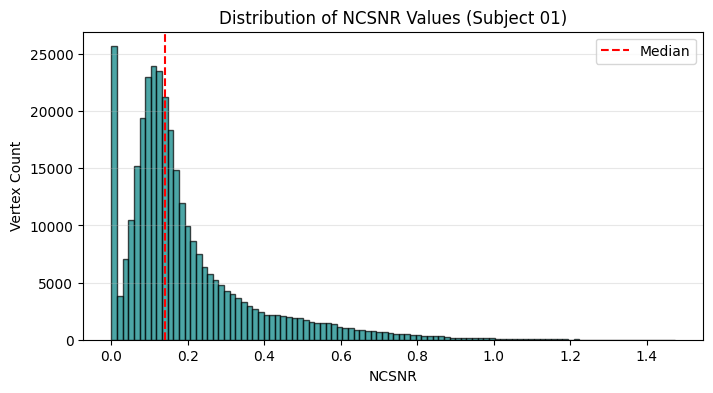

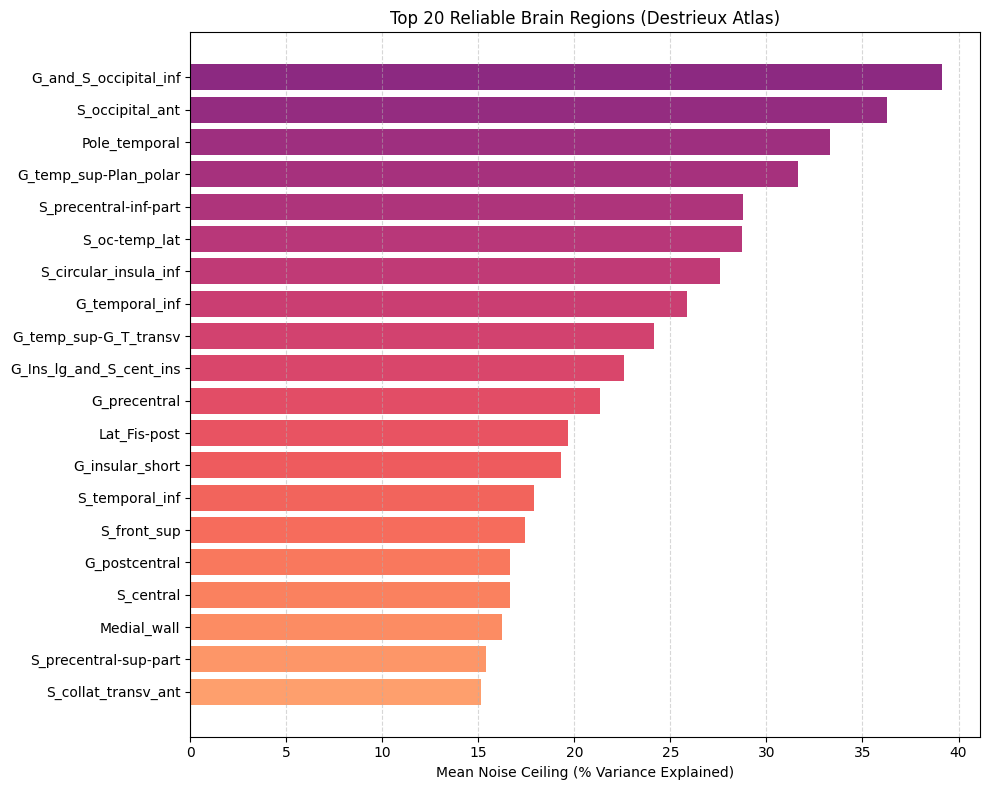

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from nilearn import plotting

lh_img = nib.load(lh_path)
rh_img = nib.load(rh_path)

# 1. Histogram of NCSNR values (original high-res data)
all_ncsnr = np.concatenate([np.squeeze(lh_img.get_fdata()), 
                            np.squeeze(rh_img.get_fdata())])

plt.figure(figsize=(8, 4))
plt.hist(all_ncsnr, bins=100, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(np.median(all_ncsnr), color='red', linestyle='dashed', label='Median')
plt.title('Distribution of NCSNR Values (Subject 01)')
plt.xlabel('NCSNR')
plt.ylabel('Vertex Count')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Histogram of NCSNR values')
plt.show()

# 2. Cortical Surface Plot (Noise Ceiling)
plotting.plot_surf_stat_map(
    fsa_low.infl_left, nc_lh_f5, 
    hemi='left', view='lateral',
    bg_map=fsa_low.sulc_left, 
    title='Noise Ceiling (% Variance Explained)',
    cmap='viridis', threshold=10,
    colorbar=True, output_file='cortical_surface_plot.png')


# 3. Cortical Surface Plot with Destrieux Parcel Overlay 
plotting.plot_surf_roi(
    fsa_low.infl_left, roi_map=destrieux.map_left,
    hemi='left', view='lateral',
    bg_map=fsa_low.sulc_left,
    title='Destrieux Atlas Regions',
    cmap='gist_ncar', output_file='parcel_overlay_cortical_surface_plot.png')

# 4. Parcel-wise Summary Figure 
all_stats = {**lh_stats, **rh_stats}
sorted_res = sorted(all_stats.items(), key=lambda x: x[1], reverse=True)[:20]
labels, values = zip(*sorted_res)

plt.figure(figsize=(10, 8))
colors = plt.cm.magma(np.linspace(0.4, 0.8, len(values)))
plt.barh(labels, values, color=colors)
plt.gca().invert_yaxis() 
plt.title('Top 20 Reliable Brain Regions (Destrieux Atlas)')
plt.xlabel('Mean Noise Ceiling (% Variance Explained)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('parcelwise_summary')
plt.show()

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

NOT USE SKLEARN, USES CLOSED FORM SOLVER                        
PREFER PYTORCH

### Starter code

In [49]:
from typing import Literal
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

class RepresentationalSimilarityAnalysis:
    """
    Representational Similarity Analysis (RSA).

    Given two representation matrices X and Y with the same number of conditions
    (rows), RSA:

    1. Computes a Representational Dissimilarity Matrix (RDM) for each:
       RDM_X[i, j] = dissimilarity(x_i, x_j)
       RDM_Y[i, j] = dissimilarity(y_i, y_j)

    2. Flattens the upper triangles of both RDMs and computes a correlation
       between them (Pearson or Spearman).
    """

    def __init__(
        self,
        dissimilarity: Literal["correlation", "euclidean", "cosine"] = "correlation",
        similarity_metric: Literal["pearson", "spearman"] = "spearman",
    ):
       
        self.dissimilarity = dissimilarity
        self.similarity_metric = similarity_metric

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.

        Parameters
        ----------
        X, Y : np.ndarray
            Arrays of shape (n_conditions, ...) that may need to be flattened
            along feature dimensions.

        Returns
        -------
        rsa_similarity : float
            Correlation between the vectorized upper triangles of the two RDMs.
        """
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        preprocess X and Y, compute their RDMs, and compare them.
        """
        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)
            print(f"Flattened X to shape {X.shape}")
        if Y.ndim > 2:
            Y = Y.reshape(Y.shape[0], -1)
            print(f"Flattened Y to shape {Y.shape}")

        return self.compare_rdms(self.compute_rdm(X), self.compute_rdm(Y))

    def compute_rdm(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the Representational Dissimilarity Matrix (RDM)
        for a given representation matrix X.

        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, n_features).

        Returns
        -------
        rdm : np.ndarray
            Array of shape (n_conditions, n_conditions) with pairwise dissimilarities.
        """
        
        if self.dissimilarity == "correlation":
            # Dissimilarity = 1 - Pearson correlation
            corr = np.corrcoef(X)
            rdm = 1 - corr
            return rdm
        if self.dissimilarity == "euclidean":
            # Dissimilarity = Euclidean distance
            rdm = squareform(pdist(X, metric='euclidean'))
            return rdm
        if self.dissimilarity == "cosine":
            # Dissimilarity = 1 - Cosine similarity
            rdm = squareform(pdist(X, metric='cosine'))
            return rdm

    def compare_rdms(self, rdm1: np.ndarray, rdm2: np.ndarray) -> float:
        """
        Compare two RDMs by correlating their upper triangles.
        """
        #flatten upper triangles
        triu_indices = np.triu_indices_from(rdm1, k=1)
        rdm1_vec = rdm1[triu_indices]
        rdm2_vec = rdm2[triu_indices]

        # compute rdm
        if self.similarity_metric == "pearson":
            return np.corrcoef(rdm1_vec, rdm2_vec)[0, 1]
        if self.similarity_metric == "spearman":
            return spearmanr(rdm1_vec, rdm2_vec)[0]


## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [50]:
import numpy as np

class CenteredKernelAlignment:
    """
    Unbiased linear CKA only.

    Parameters
    ----------
    eps : float
        Small constant for numerical stability.
    dtype : np.dtype
        Data type used for computations.
    """

    def __init__(
        self,
        eps: float = 1e-8,
        dtype: np.dtype = np.float64,
    ):
        self.eps = eps
        self.dtype = dtype

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X).astype(self.dtype)
        Y = np.asarray(Y).astype(self.dtype)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"Batch sizes must match along axis 0: {X.shape[0]} vs {Y.shape[0]}"
            )

        # Flatten to (n_samples, n_features)
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(Y.shape[0], -1)

        return self._unbiased_linear_cka(X, Y)

    def _unbiased_linear_hsic(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased HSIC estimator for the linear kernel.

        X : [n, d_x]
        Y : [n, d_y]
        """
        n = X.shape[0]
        # Compute linear kernels
        K = X @ X.T
        L = Y @ Y.T

        # Centering matrix
        H = np.eye(n) - np.ones((n, n)) / n

        # Unbiased HSIC estimator
        #zero the diagonal of K and L
        np.fill_diagonal(K, 0)
        np.fill_diagonal(L, 0)
        #(1/(n-1)^2)*trace(KHLH)
        hsic_unb = np.sum((H @ K @ H) * L) / ((n - 1)**2)
        return hsic_unb

    def _unbiased_linear_cka(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased linear CKA:

            CKA_unb(X, Y) =
                HSIC_unb(X, Y) / sqrt(HSIC_unb(X, X) * HSIC_unb(Y, Y))
        """
        
        return self._unbiased_linear_hsic(X, Y) / np.sqrt(
            self._unbiased_linear_hsic(X, X) * self._unbiased_linear_hsic(Y, Y) + self.eps
        )

## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [51]:
# TODO: implement RSA
# TODO: implement unbiased linear CKA
# TODO: compute scores across layers
# TODO: compare across models and ROIs / time windows

### Prepare paths

In [52]:
#define paths
neural_datasets = "/shared/NX-414/data"
extracted_features = "/shared/NX-414/extracted_features"

tvsd = neural_datasets + "/tvsd.h5"
eeg = neural_datasets + "/things_eeg2.h5"
eeg_test = neural_datasets + "/things_eeg2-test_reps.h5"
nsd_roi = neural_datasets + "/nsd_func1pt8mm_individualROIs.h5"
nsd_ncsnr_l = neural_datasets + "/nsd-subj01-ncsnr-lh.mgh"
nsd_ncsnr_r = neural_datasets + "/nsd-subj01-ncsnr-rh.mgh"

qwen = extracted_features + "/Qwen3-VL-2B-Instruct"  
res = extracted_features + "/adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"

qwen_nsd = qwen + "/nsd_stimuli.h5"
qwen_things = qwen + "/things_stimuli.h5"

res_nsd = res + "/nsd_stimuli.h5"
res_things = res + "/things_stimuli.h5"

nsd = neural_datasets + "/nsd_func1pt8mm_individualROIs.h5"

def fast_h5_read(h5_dataset, indices):
    """Reads a subset from an HDF5 file efficiently without loading the whole file."""
    # 1. Find the order that sorts the indices
    sort_order = np.argsort(indices)
    sorted_indices = indices[sort_order]
    
    # 2. Read only the sorted subset directly from disk (Extremely fast)
    # h5py requires the indices to be a list or a boolean mask
    subset_data = h5_dataset[sorted_indices.tolist()]
    
    # 3. Restore the original aligned order
    original_order_data = np.empty_like(subset_data)
    original_order_data[sort_order] = subset_data
    
    return original_order_data

    
# 1. Instantiate your metric classes
rsa_metric = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
cka_metric = CenteredKernelAlignment()

# Define layers
qwen_layers = [
    "/features/visual-blocks-2", "/features/visual-blocks-6", 
    "/features/visual-blocks-10", "/features/visual-blocks-14", 
    "/features/visual-blocks-18", "/features/visual-blocks-22",
    "/features/language_model-layers-3", "/features/language_model-layers-8",
    "/features/language_model-layers-11", "/features/language_model-layers-16"
]

res_layers = [
    "/features/layer1-0", "/features/layer2-0", 
    "/features/layer3-0", "/features/layer3-5", "/features/layer3-10", 
    "/features/layer3-15", "/features/layer3-20", "/features/layer3-25", 
    "/features/layer3-30", "/features/layer4-1"
]


### Comparing layers within each model

In [53]:
def compare_within_model(model_path, layer_list, subset_size=1000, use_metric="RSA"):
    """
    Computes an N x N similarity matrix comparing all layers of a single model.
    Optimized to compute only the upper triangle.
    """
    n_layers = len(layer_list)
    sim_matrix = np.zeros((n_layers, n_layers))
    
    print(f"Starting intra-model comparison for {n_layers} layers...")
    
    with h5py.File(model_path, 'r') as f:
        # 1. Grab indices up to the memory limit
        total_items = f['/ids'].shape[0]
        subset_limit = min(subset_size, total_items)
        idx_subset = np.arange(subset_limit)
        
        # 2. Pre-load all layers into RAM
        print("Pre-loading layers into RAM...")
        features_cache = {}
        for layer in layer_list:
            features_cache[layer] = fast_h5_read(f[layer], idx_subset)
            
        # 3. Compute the matrix (Upper Triangle Only)
        print(f"Computing {use_metric} similarities...")
        for i, layer_A in enumerate(layer_list):
            for j in range(i, n_layers): 
                
                X_A = features_cache[layer_A]
                X_B = features_cache[layer_list[j]]
                
                # Choose metric
                if use_metric == "RSA":
                    score = rsa_metric(X_A, X_B)
                else:
                    score = cka_metric(X_A, X_B)
                
                # Mirror the result on both sides of the diagonal
                sim_matrix[i, j] = score
                sim_matrix[j, i] = score
                
    print("Done!")
    return sim_matrix


In [54]:
res_intra_rsa = compare_within_model(res_nsd, res_layers, subset_size=1000, use_metric="RSA")
qwen_intra_rsa = compare_within_model(qwen_nsd, qwen_layers, subset_size=1000, use_metric="RSA")
res_intra_cka = compare_within_model(res_nsd, res_layers, subset_size=1000, use_metric="CKA")
qwen_intra_cka = compare_within_model(qwen_nsd, qwen_layers, subset_size=1000, use_metric="CKA")

Starting intra-model comparison for 10 layers...
Pre-loading layers into RAM...
Computing RSA similarities...
Done!
Starting intra-model comparison for 10 layers...
Pre-loading layers into RAM...
Computing RSA similarities...
Done!
Starting intra-model comparison for 10 layers...
Pre-loading layers into RAM...
Computing CKA similarities...
Done!
Starting intra-model comparison for 10 layers...
Pre-loading layers into RAM...
Computing CKA similarities...
Done!


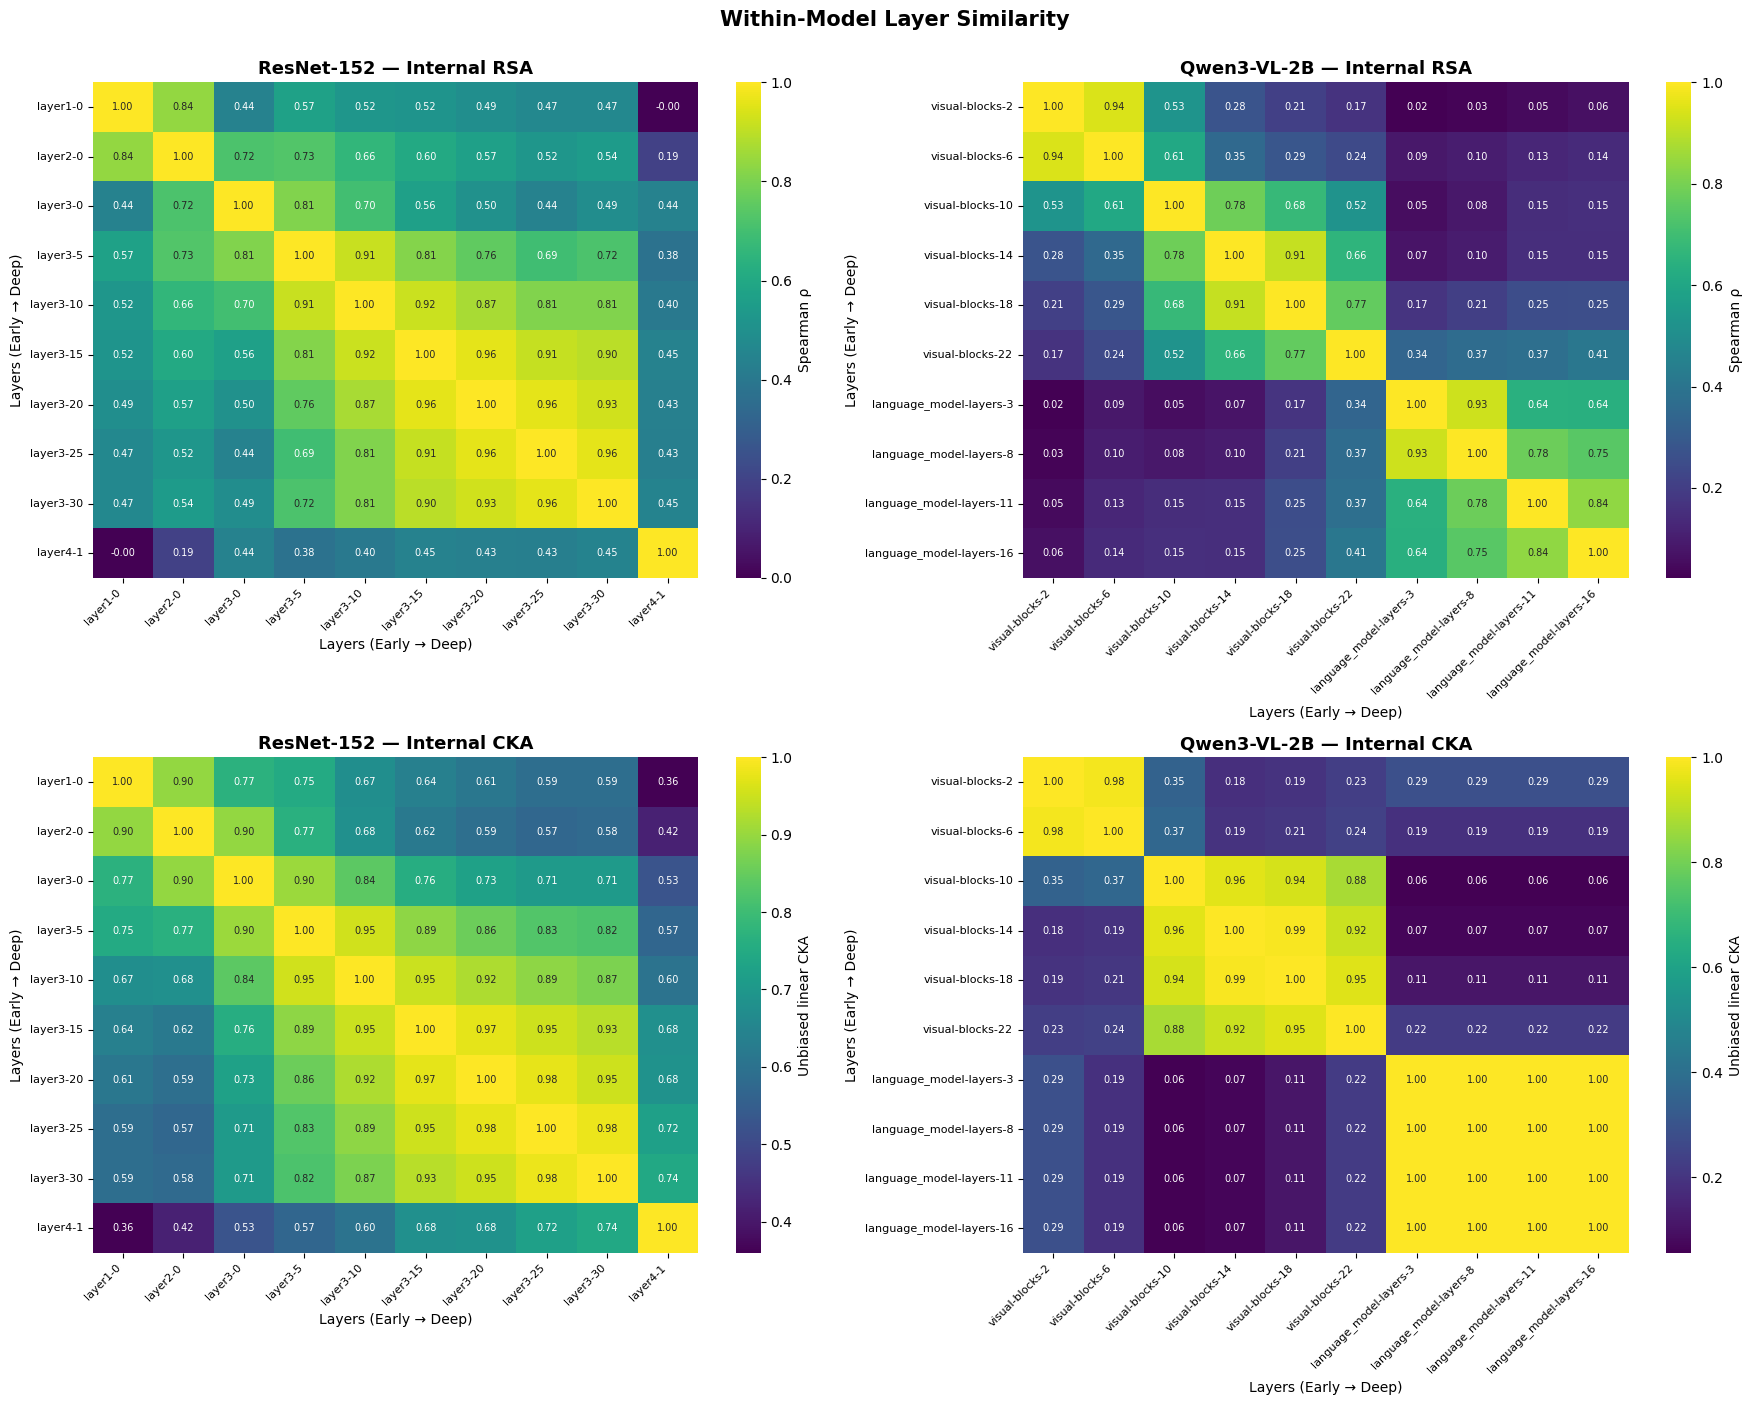

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_intra_model_grid(matrices, layer_lists, titles, metric_labels, suptitle=None):
    """
    2x2 grid of intra-model similarity heatmaps.

    Parameters
    ----------
    matrices : list of 4 np.ndarray (square similarity matrices)
    layer_lists : list of 4 lists of layer names (one per matrix)
    titles : list of 4 strings (subplot titles)
    metric_labels : list of 4 strings (colorbar labels, e.g. "RSA Score")
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    for ax, mat, layers, title, metric in zip(
        axes.flat, matrices, layer_lists, titles, metric_labels
    ):
        clean = [name.split('/')[-1] for name in layers]
        sns.heatmap(
            mat,
            xticklabels=clean,
            yticklabels=clean,
            cmap="viridis",
            annot=True,
            fmt=".2f",
            cbar_kws={'label': metric},
            ax=ax,
            annot_kws={"size": 7},
        )
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Layers (Early → Deep)', fontsize=10)
        ax.set_ylabel('Layers (Early → Deep)', fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)
        # seaborn's rotation doesn't set ha by default — fix label alignment
        for lbl in ax.get_xticklabels():
            lbl.set_ha('right')

    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight='bold', y=1.00)

    plt.tight_layout()
    plt.savefig("fig_2_3_within_model_rsa_cka.png", dpi=200, bbox_inches="tight")
    plt.show()


plot_intra_model_grid(
    matrices=[res_intra_rsa, qwen_intra_rsa, res_intra_cka, qwen_intra_cka],
    layer_lists=[res_layers, qwen_layers, res_layers, qwen_layers],
    titles=[
        "ResNet-152 — Internal RSA",
        "Qwen3-VL-2B — Internal RSA",
        "ResNet-152 — Internal CKA",
        "Qwen3-VL-2B — Internal CKA",
    ],
    metric_labels=["Spearman ρ", "Spearman ρ", "Unbiased linear CKA", "Unbiased linear CKA"],
    suptitle="Within-Model Layer Similarity",
)

### Comparing the two models

In [56]:
def compare_models(qwen_path, res_path, metric, subset_size=1000):
    """
    Computes a layer-to-layer similarity matrix between two different models
    using the given metric (e.g. rsa_metric or cka_metric).
    """
    layer_sim_matrix = np.zeros((len(qwen_layers), len(res_layers)))
    print("Start model comparison")
    
    with h5py.File(qwen_path, 'r') as f_qwen, h5py.File(res_path, 'r') as f_res:
        print("h5 start")
        qwen_ids = f_qwen['/ids'][:]
        res_ids = f_res['/ids'][:]
        
        df_q = pd.DataFrame({'id': qwen_ids, 'q_idx': np.arange(len(qwen_ids))})
        df_r = pd.DataFrame({'id': res_ids, 'r_idx': np.arange(len(res_ids))})
        
        merged = df_q.merge(df_r, on='id')
        
        q_idx = merged['q_idx'].values[:subset_size]
        r_idx = merged['r_idx'].values[:subset_size]
        print("ids found")

        print("Pre-loading ResNet layers to RAM...")
        res_features_cache = {
            r_layer: fast_h5_read(f_res[r_layer], r_idx) for r_layer in res_layers
        }
        
        for i, q_layer in enumerate(qwen_layers):
            X_qwen = fast_h5_read(f_qwen[q_layer], q_idx)
            print(f"Comparing Qwen: {q_layer}")
            
            for j, r_layer in enumerate(res_layers):
                X_res = res_features_cache[r_layer]
                layer_sim_matrix[i, j] = metric(X_qwen, X_res)
                
    return layer_sim_matrix

In [57]:
cross_rsa = compare_models(qwen_nsd, res_nsd, rsa_metric)
cross_cka = compare_models(qwen_nsd, res_nsd, cka_metric)

Start model comparison
h5 start
ids found
Pre-loading ResNet layers to RAM...
Comparing Qwen: /features/visual-blocks-2
Comparing Qwen: /features/visual-blocks-6
Comparing Qwen: /features/visual-blocks-10
Comparing Qwen: /features/visual-blocks-14
Comparing Qwen: /features/visual-blocks-18
Comparing Qwen: /features/visual-blocks-22
Comparing Qwen: /features/language_model-layers-3
Comparing Qwen: /features/language_model-layers-8
Comparing Qwen: /features/language_model-layers-11
Comparing Qwen: /features/language_model-layers-16
Start model comparison
h5 start
ids found
Pre-loading ResNet layers to RAM...
Comparing Qwen: /features/visual-blocks-2
Comparing Qwen: /features/visual-blocks-6
Comparing Qwen: /features/visual-blocks-10
Comparing Qwen: /features/visual-blocks-14
Comparing Qwen: /features/visual-blocks-18
Comparing Qwen: /features/visual-blocks-22
Comparing Qwen: /features/language_model-layers-3
Comparing Qwen: /features/language_model-layers-8
Comparing Qwen: /features/lang

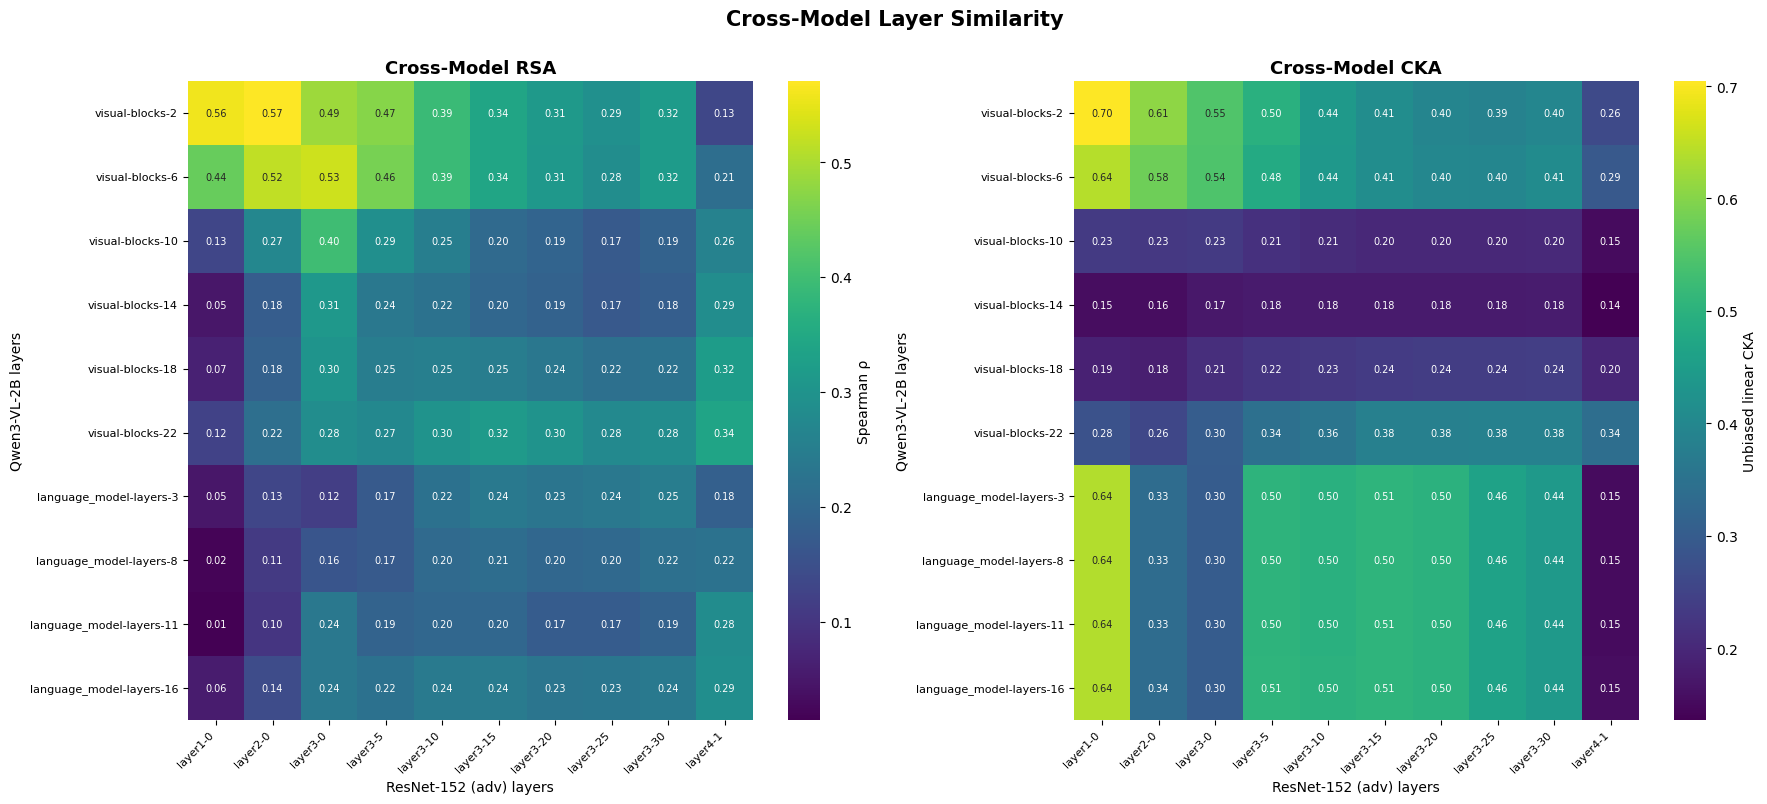

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_cross_model_pair(rsa_mat, cka_mat, row_layers, col_layers,
                          row_label="Qwen3-VL-2B layers",
                          col_label="ResNet-152 (adv) layers",
                          suptitle="Cross-Model Layer Similarity"):
    clean_rows = [n.split('/')[-1] for n in row_layers]
    clean_cols = [n.split('/')[-1] for n in col_layers]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    panels = [
        (axes[0], rsa_mat, "Cross-Model RSA",  "Spearman ρ"),
        (axes[1], cka_mat, "Cross-Model CKA",  "Unbiased linear CKA"),
    ]

    for ax, mat, title, cbar in panels:
        sns.heatmap(
            mat,
            xticklabels=clean_cols,
            yticklabels=clean_rows,
            cmap="viridis",
            annot=True,
            fmt=".2f",
            cbar_kws={'label': cbar},
            ax=ax,
            annot_kws={"size": 7},
        )
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel(col_label, fontsize=10)
        ax.set_ylabel(row_label, fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', rotation=0, labelsize=8)
        for lbl in ax.get_xticklabels():
            lbl.set_ha('right')

    fig.suptitle(suptitle, fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig("fig_2_3_cross_model_rsa_cka.png", dpi=200, bbox_inches="tight")
    plt.show()


plot_cross_model_pair(cross_rsa, cross_cka, qwen_layers, res_layers)

### ROI-Wise Analysis for NSD

In [59]:
def evaluate_model_vs_brain_nsd(model_path, brain_path, layer_list, subject="subj01", rois=["V1v", "hV4", "FFA-1"]):
    """
    Computes Layer-wise RSA and CKA across Human Brain ROIs for the NSD dataset.
    """
    results_rsa = {roi: [] for roi in rois}
    results_cka = {roi: [] for roi in rois}
    
    with h5py.File(model_path, 'r') as f_model, h5py.File(brain_path, 'r') as f_brain:
        
        # 1. Load the raw IDs specifically for this subject's test set
        model_ids = f_model['/ids'][:]
        brain_ids = f_brain[f'/test/stimulus_ids/{subject}'][:]
        
        # 2. Sanitize types to standard strings (Crucial fix from earlier)
        model_ids_str = model_ids.astype(str)
        brain_ids_str = np.array([x.decode('utf-8') if isinstance(x, bytes) else str(x) for x in brain_ids])
        
        # 3. Fast Pandas alignment
        df_m = pd.DataFrame({'id': model_ids_str, 'model_idx': np.arange(len(model_ids))})
        df_b = pd.DataFrame({'id': brain_ids_str, 'brain_idx': np.arange(len(brain_ids))})
        
        merged = df_m.merge(df_b, on='id')
        if merged.empty:
            raise ValueError("Merge failed: 0 intersecting IDs found. Check your dataset alignment.")
            
        model_idx = merged['model_idx'].values
        brain_idx = merged['brain_idx'].values
        print(f"Successfully aligned {len(model_idx)} stimuli for {subject}.")
        
        # 4. Pre-load brain matrices for the selected ROIs
        brain_data = {}
        for roi in rois:
            # Slices just the matching test IDs for the selected ROI
            roi_path = f'/test/neural_data/{subject}/{roi}'
            brain_data[roi] = f_brain[roi_path][:][brain_idx]

        # 5. Loop through model layers using fast_h5_read
        for layer in layer_list:
            X_model = fast_h5_read(f_model[layer], model_idx)
            print(f"Computing metrics for {layer}...")
            
            for roi in rois:
                Y_brain = brain_data[roi]
                
                # Compute and store
                rsa_score = rsa_metric(X_model, Y_brain)
                cka_score = cka_metric(X_model, Y_brain)
                
                results_rsa[roi].append(rsa_score)
                results_cka[roi].append(cka_score)
                
    return results_rsa, results_cka

In [60]:
# Run the function on Subject 1
qwen_rsa_human, qwen_cka_human = evaluate_model_vs_brain_nsd(
    model_path=qwen_nsd, 
    brain_path=nsd, 
    layer_list=qwen_layers,
    subject="subj01",
    rois = ["V1v", "V2v", "V3v", "hV4", "FFA-1", "VWFA-1", "PPA", "OPA", "EBA"]
)

Successfully aligned 1000 stimuli for subj01.
Computing metrics for /features/visual-blocks-2...
Computing metrics for /features/visual-blocks-6...
Computing metrics for /features/visual-blocks-10...
Computing metrics for /features/visual-blocks-14...
Computing metrics for /features/visual-blocks-18...
Computing metrics for /features/visual-blocks-22...
Computing metrics for /features/language_model-layers-3...
Computing metrics for /features/language_model-layers-8...
Computing metrics for /features/language_model-layers-11...
Computing metrics for /features/language_model-layers-16...


In [61]:
res_rsa_human, res_cka_human = evaluate_model_vs_brain_nsd(
    model_path=res_nsd, 
    brain_path=nsd, 
    layer_list=res_layers,
    subject="subj01",
    rois = ["V1v", "V2v", "V3v", "hV4", "FFA-1", "VWFA-1", "PPA", "OPA", "EBA"]
)

Successfully aligned 1000 stimuli for subj01.
Computing metrics for /features/layer1-0...
Computing metrics for /features/layer2-0...
Computing metrics for /features/layer3-0...
Computing metrics for /features/layer3-5...
Computing metrics for /features/layer3-10...
Computing metrics for /features/layer3-15...
Computing metrics for /features/layer3-20...
Computing metrics for /features/layer3-25...
Computing metrics for /features/layer3-30...
Computing metrics for /features/layer4-1...


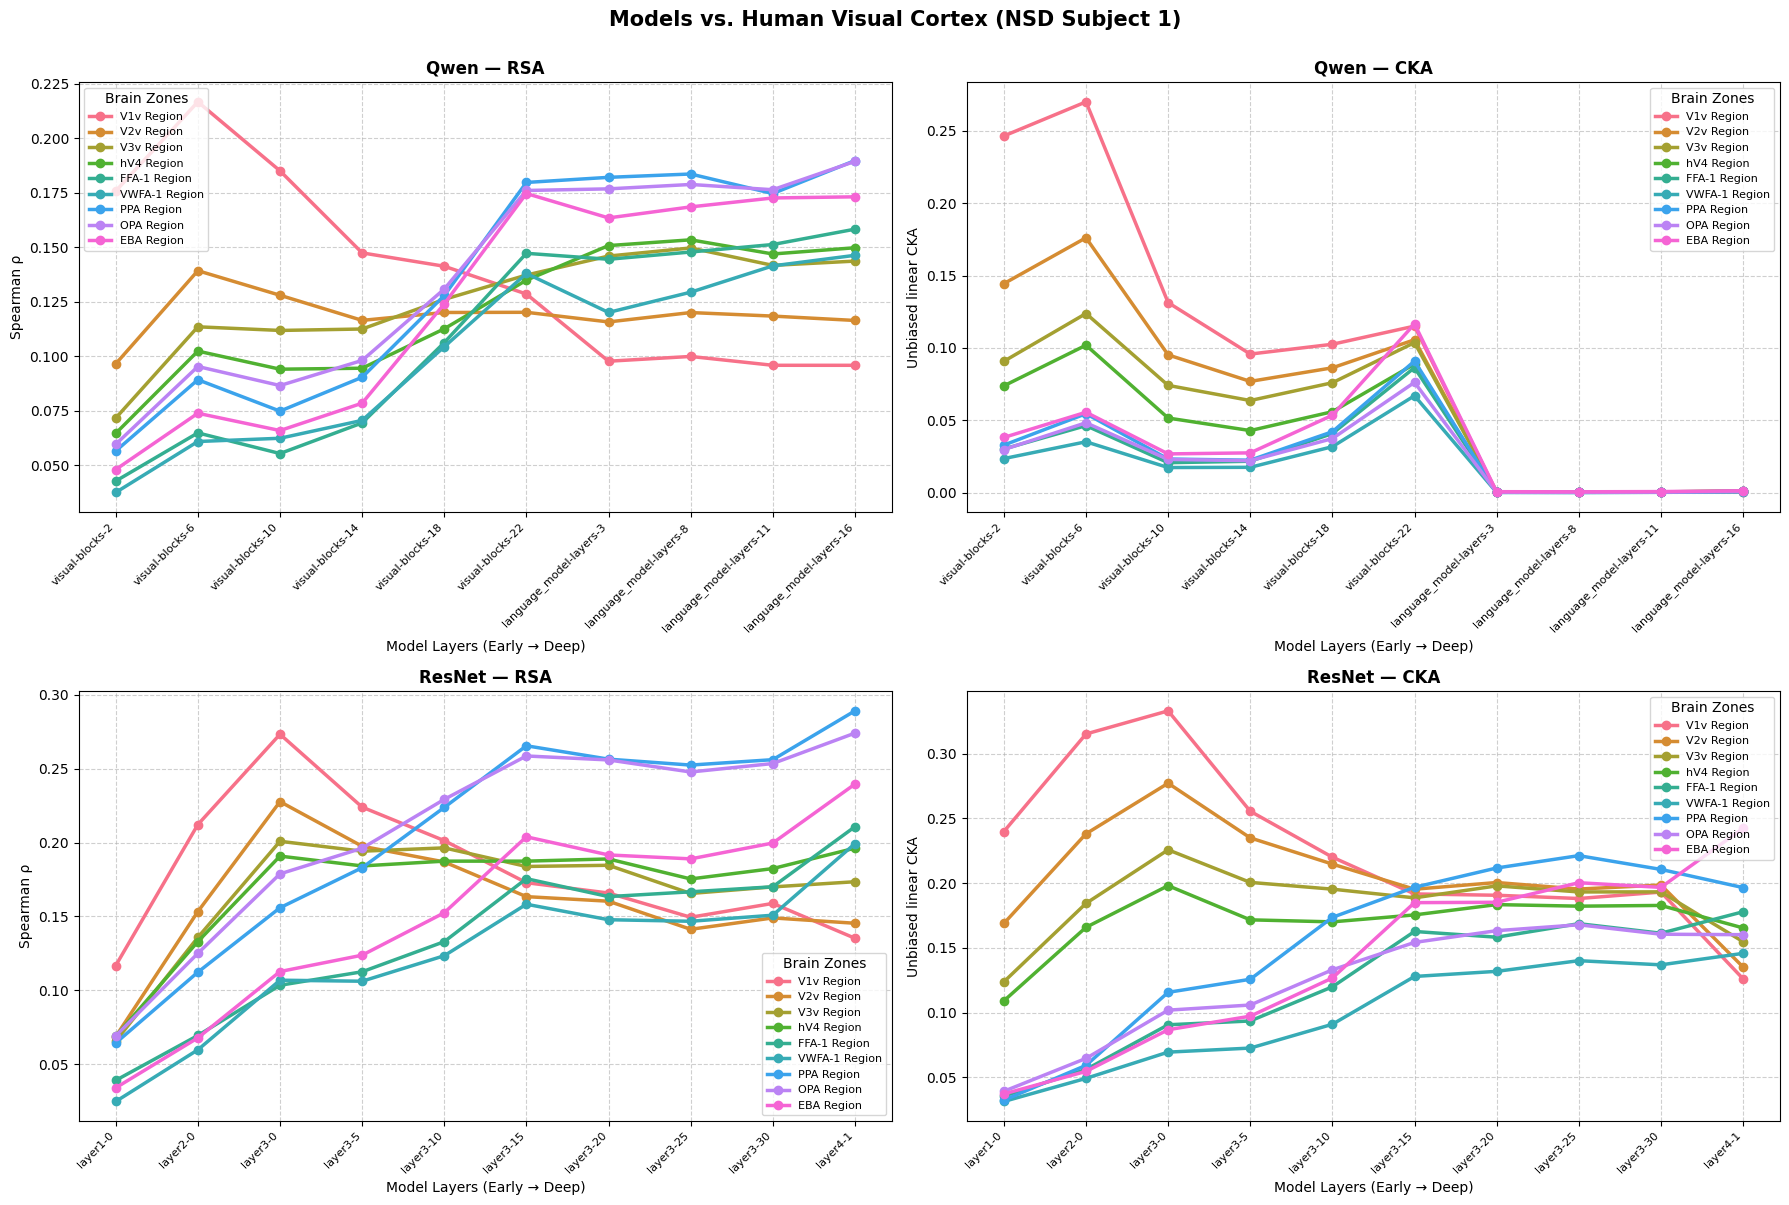

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_model_vs_brain_grid(panels, title="Model vs Brain"):
    """
    2x2 grid of layer-wise alignment line plots.

    panels : list of 4 dicts, one per subplot, each with keys:
        'results_dict' : {roi: [scores per layer]}
        'layer_names'  : list of layer paths
        'title'        : subplot title
        'ylabel'       : y-axis label
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    for ax, p in zip(axes.flat, panels):
        clean_layers = [n.split('/')[-1] for n in p['layer_names']]
        rois = list(p['results_dict'].keys())
        colors = sns.color_palette("husl", len(rois))

        for i, roi in enumerate(rois):
            ax.plot(clean_layers, p['results_dict'][roi],
                    marker='o', linewidth=2.5,
                    label=f'{roi} Region', color=colors[i])

        ax.set_title(p['title'], fontsize=12, fontweight='bold')
        ax.set_xlabel('Model Layers (Early → Deep)', fontsize=10)
        ax.set_ylabel(p['ylabel'], fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        for lbl in ax.get_xticklabels():
            lbl.set_ha('right')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(title="Brain Zones", loc='best', fontsize=8)

    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig("fig_2_3_model_vs_brain_grid.png", dpi=200, bbox_inches="tight")
    plt.show()


plot_model_vs_brain_grid(
    panels=[
        {'results_dict': qwen_rsa_human,   'layer_names': qwen_layers,
         'title': "Qwen — RSA",   'ylabel': "Spearman ρ"},
        {'results_dict': qwen_cka_human,   'layer_names': qwen_layers,
         'title': "Qwen — CKA",   'ylabel': "Unbiased linear CKA"},
        {'results_dict': res_rsa_human, 'layer_names': res_layers,
         'title': "ResNet — RSA", 'ylabel': "Spearman ρ"},
        {'results_dict': res_cka_human, 'layer_names': res_layers,
         'title': "ResNet — CKA", 'ylabel': "Unbiased linear CKA"},
    ],
    title="Models vs. Human Visual Cortex (NSD Subject 1)",
)

### Compute RSA and CKA similarity for EEG and TVSD (will be used in part 2.4)

In [63]:
import pandas as pd

def results_to_csv_rows(rsa_results, cka_results, layer_list,
                        model, dataset, subject):
    """One row per (roi, layer); target = '{subject}/{roi}'."""
    rows = []
    for i, layer in enumerate(layer_list):
        for roi in rsa_results.keys():
            rows.append({
                "model":   model,
                "dataset": dataset,
                "target":  f"{subject}/{roi}",
                "layer":   layer,
                "rsa":     rsa_results[roi][i],
                "cka":     cka_results[roi][i],
            })
    return pd.DataFrame(rows)

In [64]:
def evaluate_model_vs_brain_tvsd(
    model_path,
    brain_path,
    layer_list,
    subject="monkeyF",
    rois=["V1", "V4", "IT"],
    split="test",
):
    """
    Computes Layer-wise RSA and CKA across Monkey Brain ROIs for the TVSD (THINGS) dataset.

    TVSD layout differs from NSD: stimulus_ids are stored once per split
    (shared across subjects), not nested per-subject.
    """
    results_rsa = {roi: [] for roi in rois}
    results_cka = {roi: [] for roi in rois}

    with h5py.File(model_path, 'r') as f_model, h5py.File(brain_path, 'r') as f_brain:

        # 1. Load raw IDs. Note: stimulus_ids lives at the split level in TVSD.
        model_ids = f_model['/ids'][:]
        brain_ids = f_brain[f'/{split}/stimulus_ids'][:]

        # 2. Sanitize types to standard strings
        model_ids_str = model_ids.astype(str)
        brain_ids_str = np.array(
            [x.decode('utf-8') if isinstance(x, bytes) else str(x) for x in brain_ids]
        )

        # 3. Fast Pandas alignment
        df_m = pd.DataFrame({'id': model_ids_str, 'model_idx': np.arange(len(model_ids))})
        df_b = pd.DataFrame({'id': brain_ids_str, 'brain_idx': np.arange(len(brain_ids))})

        merged = df_m.merge(df_b, on='id')
        if merged.empty:
            raise ValueError("Merge failed: 0 intersecting IDs found. Check your dataset alignment.")

        model_idx = merged['model_idx'].values
        brain_idx = merged['brain_idx'].values
        print(f"Successfully aligned {len(model_idx)} stimuli for {subject} ({split} split).")

        # 4. Pre-load brain matrices for the selected ROIs
        brain_data = {}
        for roi in rois:
            roi_path = f'/{split}/neural_data/{subject}/{roi}'
            brain_data[roi] = f_brain[roi_path][:][brain_idx]

        # 5. Loop through model layers using fast_h5_read
        import time
        for layer in layer_list:
            t0 = time.time()
            X_model = fast_h5_read(f_model[layer], model_idx)
            t_load = time.time() - t0
            for roi in rois:
                t1 = time.time()
                rsa = rsa_metric(X_model, brain_data[roi])
                t_rsa = time.time() - t1
                t2 = time.time()
                cka = cka_metric(X_model, brain_data[roi])
                t_cka = time.time() - t2
            
                results_rsa[roi].append(rsa)   # ← add this
                results_cka[roi].append(cka)   # ← and this

    print(f"{layer} {roi}: load={t_load:.1f}s rsa={t_rsa:.2f}s cka={t_cka:.2f}s shape={X_model.shape}")

    return results_rsa, results_cka

In [65]:
res_rsa_results, res_cka_results = evaluate_model_vs_brain_tvsd(
    model_path=res_things,
    brain_path=tvsd,
    layer_list=res_layers,
    subject="monkeyF",
    rois=["V1", "V4", "IT"],
    split="test",
)
res_rsa_results


Successfully aligned 100 stimuli for monkeyF (test split).
/features/layer4-1 IT: load=0.2s rsa=0.02s cka=0.03s shape=(100, 30000)


{'V1': [np.float64(0.10795887222719112),
  np.float64(0.18920888894317317),
  np.float64(0.19767530868314012),
  np.float64(0.13313830585446024),
  np.float64(0.09492353145470811),
  np.float64(0.07035239733933038),
  np.float64(0.07190040092719446),
  np.float64(0.06727589897147744),
  np.float64(0.07360600427167065),
  np.float64(0.08549922925796014)],
 'V4': [np.float64(0.06973402083426575),
  np.float64(0.13418295408079875),
  np.float64(0.21348799763178636),
  np.float64(0.17324916796643822),
  np.float64(0.1704752899619823),
  np.float64(0.12897925608866806),
  np.float64(0.13251899279681015),
  np.float64(0.12195833937121467),
  np.float64(0.12302520613522032),
  np.float64(0.1495837993232173)],
 'IT': [np.float64(0.07051888811237356),
  np.float64(0.1622908227120883),
  np.float64(0.2638129563598365),
  np.float64(0.23977535228945296),
  np.float64(0.25484894423267274),
  np.float64(0.23198461269628293),
  np.float64(0.23936651245741142),
  np.float64(0.24584284571186474),
  np

In [66]:
qwen_rsa_results, qwen_cka_results = evaluate_model_vs_brain_tvsd(
    model_path=qwen_things,
    brain_path=tvsd,
    layer_list=qwen_layers,
    subject="monkeyF",     
    rois=["V1", "V4", "IT"],
    split="test",            
)
qwen_rsa_results


Successfully aligned 100 stimuli for monkeyF (test split).
/features/language_model-layers-16 IT: load=0.2s rsa=0.02s cka=0.03s shape=(100, 30000)


{'V1': [np.float64(0.12379310871206409),
  np.float64(0.12955073580639484),
  np.float64(0.09250792429067099),
  np.float64(0.06378104307819475),
  np.float64(0.05674943208977594),
  np.float64(0.047288342748594364),
  np.float64(0.033892310900181806),
  np.float64(0.03363164583681233),
  np.float64(0.020044847052069457),
  np.float64(0.022618828068157945)],
 'V4': [np.float64(0.044791638599801585),
  np.float64(0.06751867119077662),
  np.float64(0.03559646815839255),
  np.float64(0.036148123157362495),
  np.float64(0.041385770141859866),
  np.float64(0.06372658659194003),
  np.float64(0.05183978133426431),
  np.float64(0.05385469398262378),
  np.float64(0.05282526706085503),
  np.float64(0.060642499832982394)],
 'IT': [np.float64(0.07604547413467473),
  np.float64(0.10804838453169179),
  np.float64(0.08167840507973813),
  np.float64(0.09713059004530702),
  np.float64(0.10859524348306206),
  np.float64(0.11341867896326768),
  np.float64(0.08416840297379337),
  np.float64(0.096414707987

In [67]:
df_qwen_tvsd = results_to_csv_rows(
    qwen_rsa_results, qwen_cka_results, qwen_layers,
    model="Qwen3-VL-2B-Instruct",
    dataset="TVSD",
    subject="monkeyF",
)

df_res_tvsd = results_to_csv_rows(
    res_rsa_results, res_cka_results, res_layers,
    model="adv_resnet152",
    dataset="TVSD",
    subject="monkeyF",
)
tvsd_rsa_cka = pd.concat([df_qwen_tvsd, df_res_tvsd], ignore_index=True)
tvsd_rsa_cka.head()

,model,dataset,target,layer,rsa,cka
0,Qwen3-VL-2B-Instruct,TVSD,monkeyF/V1,/features/visual-blocks-2,0.123793,0.119701
1,Qwen3-VL-2B-Instruct,TVSD,monkeyF/V4,/features/visual-blocks-2,0.044792,0.047900
2,Qwen3-VL-2B-Instruct,TVSD,monkeyF/IT,/features/visual-blocks-2,0.076045,0.050974
3,Qwen3-VL-2B-Instruct,TVSD,monkeyF/V1,/features/visual-blocks-6,0.129551,0.138900
4,Qwen3-VL-2B-Instruct,TVSD,monkeyF/V4,/features/visual-blocks-6,0.067519,0.070886


In [68]:
df_qwen_nsd = results_to_csv_rows(
    qwen_rsa_human, qwen_cka_human, qwen_layers,
    model="Qwen3-VL-2B-Instruct",
    dataset="NSD",
    subject="subj01",
)

df_res_nsd = results_to_csv_rows(
    res_rsa_human, res_cka_human, res_layers,
    model="adv_resnet152",
    dataset="NSD",
    subject="subj01",
)
fmri_rsa_cka = pd.concat([df_qwen_nsd, df_res_nsd], ignore_index=True)
fmri_rsa_cka.head()

,model,dataset,target,layer,rsa,cka
0,Qwen3-VL-2B-Instruct,NSD,subj01/V1v,/features/visual-blocks-2,0.175779,0.246297
1,Qwen3-VL-2B-Instruct,NSD,subj01/V2v,/features/visual-blocks-2,0.096574,0.144399
2,Qwen3-VL-2B-Instruct,NSD,subj01/V3v,/features/visual-blocks-2,0.071726,0.090807
3,Qwen3-VL-2B-Instruct,NSD,subj01/hV4,/features/visual-blocks-2,0.064713,0.073867
4,Qwen3-VL-2B-Instruct,NSD,subj01/FFA-1,/features/visual-blocks-2,0.042851,0.030308


In [69]:
def evaluate_model_vs_brain_eeg(
    model_path,
    brain_path,
    layer_list,
    subject="sub-01",
    rois=["occipital_parietal"],
    split="test",
):
    """
    Layer-wise RSA and CKA across EEG ROIs and ALL time points (THINGS-EEG2).

    Returns:
        results_rsa, results_cka: dict[roi] -> np.ndarray of shape (n_layers, n_times)
        time_points_s: 1D array of time points in seconds (from file attrs)
    """
    with h5py.File(model_path, 'r') as f_model, h5py.File(brain_path, 'r') as f_brain:

        # 1. Load IDs
        model_ids = f_model['/ids'][:]
        brain_ids = f_brain[f'/{split}/stimulus_ids'][:]

        # 2. Sanitize types
        model_ids_str = model_ids.astype(str)
        brain_ids_str = np.array(
            [x.decode('utf-8') if isinstance(x, bytes) else str(x) for x in brain_ids]
        )

        # 3. Align
        df_m = pd.DataFrame({'id': model_ids_str, 'model_idx': np.arange(len(model_ids))})
        df_b = pd.DataFrame({'id': brain_ids_str, 'brain_idx': np.arange(len(brain_ids))})
        merged = df_m.merge(df_b, on='id')
        if merged.empty:
            raise ValueError("Merge failed: 0 intersecting IDs found.")
        model_idx = merged['model_idx'].values
        brain_idx = merged['brain_idx'].values
        print(f"Successfully aligned {len(model_idx)} stimuli for {subject} ({split} split).")

        # 4. Time axis (seconds)
        time_points_s = np.asarray(f_brain.attrs['time_points'])
        n_times = len(time_points_s)
        print(f"Sweeping over {n_times} time points "
              f"({time_points_s[0]*1000:.0f}–{time_points_s[-1]*1000:.0f} ms).")

        # 5. Pre-load brain matrices: (n_aligned, n_channels, n_times)
        brain_data = {}
        for roi in rois:
            roi_path = f'/{split}/neural_data/{subject}/{roi}'
            full = f_brain[roi_path][:]              # (n_stim, n_channels, n_times)
            brain_data[roi] = full[brain_idx]         # (n_aligned, n_channels, n_times)

        # 6. Allocate result arrays
        n_layers = len(layer_list)
        results_rsa = {roi: np.zeros((n_layers, n_times)) for roi in rois}
        results_cka = {roi: np.zeros((n_layers, n_times)) for roi in rois}

        # 7. Layer × ROI × time loop
        for li, layer in enumerate(layer_list):
            X_model = fast_h5_read(f_model[layer], model_idx)
            print(f"Computing metrics for {layer}...")

            for roi in rois:
                Y_full = brain_data[roi]              # (n, c, t)
                for ti in range(n_times):
                    Y_brain = Y_full[:, :, ti]        # (n, c)
                    results_rsa[roi][li, ti] = rsa_metric(X_model, Y_brain)
                    results_cka[roi][li, ti] = cka_metric(X_model, Y_brain)

    return results_rsa, results_cka, time_points_s

In [70]:
qwen_rsa_eeg, qwen_cka_eeg, time_s = evaluate_model_vs_brain_eeg(
    model_path=qwen_things, brain_path=eeg,
    layer_list=qwen_layers,
    subject="sub-01",
    rois=["occipital_parietal"],
    split="test",
)

Successfully aligned 200 stimuli for sub-01 (test split).
Sweeping over 80 time points (0–790 ms).
Computing metrics for /features/visual-blocks-2...
Computing metrics for /features/visual-blocks-6...
Computing metrics for /features/visual-blocks-10...
Computing metrics for /features/visual-blocks-14...
Computing metrics for /features/visual-blocks-18...
Computing metrics for /features/visual-blocks-22...
Computing metrics for /features/language_model-layers-3...
Computing metrics for /features/language_model-layers-8...
Computing metrics for /features/language_model-layers-11...
Computing metrics for /features/language_model-layers-16...


In [71]:
res_rsa_eeg, res_cka_eeg, time_s = evaluate_model_vs_brain_eeg(
    model_path=res_things, brain_path=eeg,
    layer_list=res_layers,
    subject="sub-01",
    rois=["occipital_parietal"],
    split="test",
)

Successfully aligned 200 stimuli for sub-01 (test split).
Sweeping over 80 time points (0–790 ms).
Computing metrics for /features/layer1-0...
Computing metrics for /features/layer2-0...
Computing metrics for /features/layer3-0...
Computing metrics for /features/layer3-5...
Computing metrics for /features/layer3-10...
Computing metrics for /features/layer3-15...
Computing metrics for /features/layer3-20...
Computing metrics for /features/layer3-25...
Computing metrics for /features/layer3-30...
Computing metrics for /features/layer4-1...


In [72]:
def eeg_results_to_csv_rows(rsa_results, cka_results, layer_list, time_points_s,
                            model, dataset, subject):
    rows = []
    for li, layer in enumerate(layer_list):
        for roi, mat_rsa in rsa_results.items():
            mat_cka = cka_results[roi]
            for ti, t_s in enumerate(time_points_s):
                rows.append({
                    "model":   model,
                    "dataset": dataset,
                    "target":  f"{subject}/{roi}",
                    "layer":   layer,
                    "time_ms": float(t_s) * 1000.0,
                    "rsa":     mat_rsa[li, ti],
                    "cka":     mat_cka[li, ti],
                })
    return pd.DataFrame(rows)

qwen_eeg_rsa_cka_df = eeg_results_to_csv_rows(
    qwen_rsa_eeg, qwen_cka_eeg, qwen_layers, time_s,
    model="Qwen3-VL-2B-Instruct", dataset="EEG", subject="sub-01",
)
res_eeg_rsa_cka_df = eeg_results_to_csv_rows(
    res_rsa_eeg, res_cka_eeg, res_layers, time_s,
    model="adv_resnet152", dataset="EEG", subject="sub-01",
)
qwen_eeg_rsa_cka_df.head()

,model,dataset,target,layer,time_ms,rsa,cka
0,Qwen3-VL-2B-Instruct,EEG,sub-01/occipital_parietal,/features/visual-blocks-2,0.0,0.017064,0.012811
1,Qwen3-VL-2B-Instruct,EEG,sub-01/occipital_parietal,/features/visual-blocks-2,10.0,0.019905,0.008247
2,Qwen3-VL-2B-Instruct,EEG,sub-01/occipital_parietal,/features/visual-blocks-2,20.0,0.060463,0.032374
3,Qwen3-VL-2B-Instruct,EEG,sub-01/occipital_parietal,/features/visual-blocks-2,30.0,0.087392,0.056883
4,Qwen3-VL-2B-Instruct,EEG,sub-01/occipital_parietal,/features/visual-blocks-2,40.0,0.079138,0.078601


---

## 2.4 Predictive alignment: linear encoding models

## Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

For TVSD all targets have been used, so there is no selection criteria. For EEG2 the occipital_parietal region has shown to be the most reliable region, so the ROI has been chosen for reliability. The occipital region is heavily involved in processing of visual stimuli so it is also biologically relevant. The NSD areas follow the hierarchy of biological vision processing, starting from early visual areas which extract low-level features such as edges and contrast such as the primary visual cortex, to higher visual and association areas which integrate complex information, like the Fusiform Face Area which recognises faces and the Parahippocampal Place Area which recognises places. These areas appear to have been chosen primarily for interpretability but some of then have been shown to be very reliable.

In [73]:
# TODO: define target ROIs / regions
# TODO: load corresponding neural data

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

WHAT LAYER????

For TVSD data, the early layers are most strongly linearly aligned with V1 for both ResNet and Qwen with a pearson's correlation coefficient of ~0.8. This suggests that the initial layers of the models are strongly correlated with initial visual areas that extract low level features like edges and contrast. The middle layers of both models are well aligned with V4 (r = 0.7-0.8), which is higher up in the visual processing hierarchy while the features of the late layers of the models best predict the Inferior Temporal (IT) cortex which is the final stage of the ventral visual stream and is critical for high-level object recognition and visual categorization. 

The model features are unable to predict the EEG neural data well, with the pearson correlation coefficient <0.55 for all layers of both models. The best performance in obtained from the later layers and ResNet performs marginally better than Qwen. This may be due to the volume conduction issue in EEG data, where signals from deeper sources (e.g., V1) mix with parietal sources before reaching scalp electrodes. This spatial blurring makes it harder to isolate pure visual cortex signals and reduces linear predictability.

The areas selected to analyse the fMRI data are arranged in the hierarchy of visual processing areas, starting from V1,V2 until higher level areas (FFA-PPA). This provides a clear visualisation of how shallow layers of both the models are able to best predict neural data for early visual processing areas and similar trends for middle and late layers and visual areas. As we move through the plots arranged in the hierarchy of visual processing areas, the peak of the pearson correlation coefficient for each model layer graph shifts right. The peak is always ~0.8 suggesting strong linear alignment. The ResNet model makes better aligned predictions in the early visual regions but Qwen outperforms it in regions of higher visual processing. This can be attributed to ResNet's convolutional architecture closely mirroring the retinotopic organization and edge/orientation selectivity of early visual cortex while Qwen's vision-language transformer leverages self-attention mechanisms to integrate global context and semantic information, better capturing the abstract, category-selective representations characteristic of higher-order ventral stream areas.

In [74]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

In [75]:
DATA_DIR = "/shared/NX-414/data/"
FEAT_DIR = "/shared/NX-414/extracted_features/"

MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
MODEL_B = "Qwen3-VL-2B-Instruct"

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

my_rsa_fn = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
my_cka_fn = CenteredKernelAlignment()

Using device: cuda


In [78]:
import os
os.chdir('/home/MA2/NX-414/project/try') # Put your actual path here

from tvsd_predict import *

### TVSD

In [80]:
from tvsd_predict import *

TEST_MODE = True  

if TEST_MODE:
    print("RUNNING IN TEST MODE")
    config = {
        "n_train": 1000,                           
        "n_test": 100,                             
        "n_layers": 2,                             
        "alpha_grid": np.logspace(4, 6, 3),
        "rsa_fn": my_rsa_fn,  
        "cka_fn": my_cka_fn,
        "DEVICE": DEVICE
    }
else:
    print("RUNNING FULL PIPELINE")
    config = {
        "n_train": None,                           
        "n_test": None,                            
        "n_layers": None,                          
        "alpha_grid": np.logspace(0, 7, 15),
        "rsa_fn": my_rsa_fn,  
        "cka_fn": my_cka_fn,
        "DEVICE": DEVICE
    }

df_v1 = run_tvsd_pipeline(roi="V1", **config)
df_v4 = run_tvsd_pipeline(roi="V4", **config)
df_it = run_tvsd_pipeline(roi="IT", **config)

# Combine them later if needed
tvsd_df = pd.concat([df_v1, df_v4, df_it], ignore_index=True)
tvsd_df.head()

RUNNING IN TEST MODE

🚀 STARTING PIPELINE: monkeyF/V1

  ▶ Model A (ResNet) (2 layers)
          ep   0  loss=4.384e+04  ||β||=0.00
          ep  50  loss=2.129e+04  ||β||=1.23
          ep 100  loss=1.260e+04  ||β||=1.21
          ep 150  loss=1.255e+04  ||β||=1.21
          ep 200  loss=1.255e+04  ||β||=1.21
          ep 250  loss=1.255e+04  ||β||=1.21
        α=1.0e+04  val_r=0.4061 ◀ best so far  (1.81s)
          ep   0  loss=7.808e+04  ||β||=1.21
          ep  50  loss=3.305e+04  ||β||=0.39
          ep 100  loss=3.010e+04  ||β||=0.35
          ep 150  loss=3.024e+04  ||β||=0.35
          ep 200  loss=3.132e+04  ||β||=0.36
          ep 250  loss=3.297e+04  ||β||=0.36
        α=1.0e+05  val_r=0.3942  (1.80s)
          ep   0  loss=9.014e+04  ||β||=0.36
          ep  50  loss=4.578e+04  ||β||=0.11
          ep 100  loss=3.985e+04  ||β||=0.08
          ep 150  loss=3.977e+04  ||β||=0.07
          ep 200  loss=3.977e+04  ||β||=0.07
          ep 250  loss=3.977e+04  ||β||=0.07
       

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka
0,TVSD,Model A (ResNet),features/layer1-0,monkeyF/V1,10000.0,0.615357,0.631987,0.147409,0.133796,0.455350,0.727460
1,TVSD,Model A (ResNet),features/layer2-0,monkeyF/V1,10000.0,0.615994,0.632261,0.053368,0.017744,0.477777,0.750499
2,TVSD,Model B (Qwen3),features/language_model-layers-11,monkeyF/V1,1000000.0,0.329053,0.338058,0.030197,0.031864,0.082179,0.185454
3,TVSD,Model B (Qwen3),features/language_model-layers-16,monkeyF/V1,1000000.0,0.314979,0.323545,0.025761,0.027144,0.077639,0.172069
4,TVSD,Model A (ResNet),features/layer1-0,monkeyF/V4,10000.0,0.418604,0.426001,0.025316,0.011623,0.319279,0.384372


### EEG

In [81]:
from eeg_predict import *
TEST_MODE = True  

if TEST_MODE:
    print("RUNNING IN TEST MODE")
    config = {
        "n_train": 2000,                           
        "n_test": 200,                             
        "n_layers": 2,                             
        "alpha_grid": np.logspace(0, 7, 3), # Faster alpha grid
        "rsa_fn": my_rsa_fn,
        "cka_fn": my_cka_fn,
        "DEVICE": DEVICE
    }
else:
    print("RUNNING FULL PIPELINE")
    config = {
        "n_train": None,                           
        "n_test": None,                            
        "n_layers": None,                          
        "alpha_grid": np.logspace(0, 7, 15),
        "rsa_fn": my_rsa_fn,
        "cka_fn": my_cka_fn,
        "DEVICE": DEVICE
    }

subjects_to_test = ["sub-01"] 
roi = "occipital_parietal"
all_results = []

for sub in subjects_to_test:
    df_eeg = run_eeg_pipeline(subject=sub, roi=roi, **config) 
    all_results.append(df_eeg)

eeg_df = pd.concat(all_results, ignore_index=True)
eeg_df.head()

RUNNING IN TEST MODE

🚀 STARTING EEG PIPELINE: sub-01/occipital_parietal

  ▶ Model A (ResNet) (2 layers)
        α=1.0e+00  val_r=0.0042 ◀ best so far  (0.01s)
        α=3.2e+03  val_r=0.0077 ◀ best so far  (0.00s)
        α=1.0e+07  val_r=0.0341 ◀ best so far  (0.00s)
    [ 1/2] layer1-0                     | r=0.167 (Peak ~100ms: 0.389) | α=1e+07 | 2.4s
        α=1.0e+00  val_r=0.0166 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.0206 ◀ best so far  (0.00s)
        α=1.0e+07  val_r=0.0408 ◀ best so far  (0.00s)
    [ 2/2] layer2-0                     | r=0.192 (Peak ~100ms: 0.423) | α=1e+07 | 1.8s
  ✓ Model A (ResNet) done in 4.3s

  ▶ Model B (Qwen3) (2 layers)
        α=1.0e+00  val_r=0.0484 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.0484  (0.00s)
        α=1.0e+07  val_r=0.0293  (0.00s)
    [ 1/2] language_model-layers-11     | r=0.092 (Peak ~100ms: 0.064) | α=1e+00 | 1.8s
        α=1.0e+00  val_r=0.0415 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.0437 ◀ best so 

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,r_per_ch_t,ev_per_ch_t,r_nc_per_ch_t,ev_nc_per_ch_t,encoding_rsa,encoding_cka
0,EEG2,Model A (ResNet),features/layer1-0,occipital_parietal,1.000000e+07,0.167313,0.249619,-0.028531,-0.110478,"[[0.016152196, 0.16102391, 0.04527104, -0.0485...","[[-0.13490748, -0.095273614, -0.00059473515, -...","[[16.152195632457733, 161.02391481399536, 45.2...","[[-134907.48405456543, -95273.61392974854, -59...",0.053725,0.072826
1,EEG2,Model A (ResNet),features/layer2-0,occipital_parietal,1.000000e+07,0.191518,0.283268,-0.025511,-0.104510,"[[0.03884542, 0.17793241, 0.02814932, -0.06535...","[[-0.13387752, -0.09535968, -0.0023151636, -0....","[[38.84541988372803, 177.93241143226624, 28.14...","[[-133877.51579284668, -95359.6830368042, -231...",0.051933,0.072894
2,EEG2,Model B (Qwen3),features/language_model-layers-11,occipital_parietal,1.000000e+00,0.091854,0.136263,-4.895606,-18.218358,"[[0.0045552365, -0.020487335, -0.023325628, 0....","[[-10.618706, -9.530741, -9.163919, -10.90073,...","[[4.5552365481853485, -20.487334579229355, -23...","[[-10618705.749511719, -9530740.737915039, -91...",0.000077,0.006371
3,EEG2,Model B (Qwen3),features/language_model-layers-16,occipital_parietal,3.162278e+03,0.107209,0.162740,-3.336012,-12.480787,"[[0.00087586755, -0.014933735, -0.008183442, 0...","[[-5.7783437, -5.801626, -5.836313, -7.0670834...","[[0.875867553986609, -14.933735132217407, -8.1...","[[-5778343.677520752, -5801626.205444336, -583...",0.012731,0.012291


### FMRI

In [82]:
from fmri_predict import *

TEST_MODE = True  

if TEST_MODE:
    print("⏳ RUNNING IN TEST MODE (Fast execution)")
    config = {
        "n_train": 2000,                           
        "n_test": 200,                             
        "n_layers": 2,                             
        "alpha_grid": np.logspace(0, 7, 3), # Faster alpha grid
        "rsa_fn": my_rsa_fn,
        "cka_fn": my_cka_fn,
        "DEVICE": DEVICE
    }
else:
    print("🚀 RUNNING FULL PIPELINE (Grab a coffee)")
    config = {
        "n_train": None,                           
        "n_test": None,                            
        "n_layers": None,                          
        "alpha_grid": np.logspace(0, 7, 15),
        "rsa_fn": my_rsa_fn,
        "cka_fn": my_cka_fn,
        "DEVICE": DEVICE
    }

subject = "subj01"
rois_to_test = ["V1v", "V2v", "V3v", "hV4", "FFA-1", "VWFA-1", "PPA", "OPA", "EBA"]

fmri_df = run_nsd_pipeline(
    subject="subj01", 
    rois=rois_to_test, 
    **config
)
fmri_df.head()

⏳ RUNNING IN TEST MODE (Fast execution)

🚀 STARTING NSD PIPELINE: subj01
  Targets: ['V1v', 'V2v', 'V3v', 'hV4', 'FFA-1', 'VWFA-1', 'PPA', 'OPA', 'EBA']

  ▶ Model A (ResNet) (2 layers)
        α=1.0e+00  val_r=0.3882 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.4257 ◀ best so far  (0.00s)
        α=1.0e+07  val_r=0.3818  (0.00s)
        α=1.0e+00  val_r=0.3028 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.3382 ◀ best so far  (0.00s)
        α=1.0e+07  val_r=0.3279  (0.00s)
        α=1.0e+00  val_r=0.2590 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.2940 ◀ best so far  (0.00s)
        α=1.0e+07  val_r=0.3051 ◀ best so far  (0.00s)
        α=1.0e+00  val_r=0.1889 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.2217 ◀ best so far  (0.00s)
        α=1.0e+07  val_r=0.2688 ◀ best so far  (0.00s)
        α=1.0e+00  val_r=0.1318 ◀ best so far  (0.00s)
        α=3.2e+03  val_r=0.1562 ◀ best so far  (0.00s)
        α=1.0e+07  val_r=0.2019 ◀ best so far  (0.00s)
        α=1.0e+00

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,r_per_channel,ev_per_channel,r_nc_per_channel,ev_nc_per_channel,encoding_rsa,encoding_cka
0,FMRI,Model A (ResNet),features/layer1-0,V1v,3.162278e+03,0.454355,0.653224,0.181890,0.222769,"[0.014628326, 0.024316505, 0.050588425, 0.3009...","[-0.25550735, -0.21589208, -0.17122209, 0.0434...","[0.038135335, 0.049503125, 0.11056906, 0.52408...","[-1.736478, -0.8947457, -0.8179462, 0.131639, ...",0.508719,0.464975
1,FMRI,Model A (ResNet),features/layer1-0,V2v,3.162278e+03,0.348738,0.513688,0.061398,-0.109459,"[0.37765467, 0.10771258, 0.14979237, 0.2268969...","[0.0605368, -0.23408389, -0.2039597, -0.086724...","[0.48424953, 0.16945335, 0.31244877, 0.3749091...","[0.099533245, -0.5793473, -0.88740647, -0.2367...",0.394547,0.387116
2,FMRI,Model A (ResNet),features/layer1-0,V3v,1.000000e+07,0.285165,0.458299,0.011014,0.021338,"[0.15959655, 0.25154752, 0.1842712, 0.12437228...","[-0.0011885166, 0.006954193, 0.003589809, 0.00...","[0.4720397, 0.4340127, 0.51052946, 0.32066783,...","[-0.010397174, 0.020701963, 0.027554847, 0.017...",0.171304,0.217505
3,FMRI,Model A (ResNet),features/layer1-0,hV4,1.000000e+07,0.248927,0.432062,0.007171,0.017317,"[0.06478221, 0.16129412, 0.13345739, 0.2226206...","[-0.0077135563, 0.00022250414, -0.008457422, -...","[0.16372928, 0.34830666, 0.34744892, 0.3736299...","[-0.04927151, 0.0010375872, -0.05732376, -0.02...",0.148286,0.194149
4,FMRI,Model A (ResNet),features/layer1-0,FFA-1,1.000000e+07,0.175330,0.322997,-0.004096,-0.013251,"[0.20505375, 0.1317386, 0.042495158, 0.0884216...","[-0.016743898, -0.016931772, -0.00035095215, 0...","[0.31153238, 0.22957914, 0.09611247, 0.2465199...","[-0.03864805, -0.051421072, -0.0017952644, 0.0...",0.074185,0.063619


### Prep dataframes for data analysis

In [83]:
tvsd_rsa_cka['model'] = tvsd_rsa_cka['model'].replace({'adv_resnet152': 'Model A (ResNet)', 'Qwen3-VL-2B-Instruct': 'Model B (Qwen3)'})

tvsd_rsa_cka['layer'] = tvsd_rsa_cka['layer'].str.lstrip('/')

tvsd_df = pd.merge(
    tvsd_df, 
    tvsd_rsa_cka, 
    on=['model', 'dataset', 'layer', 'target'],
    how='left'
)
tvsd_df['target'] = tvsd_df['target'].str.split('/').str[-1]
tvsd_df.head()


,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka,rsa,cka
0,TVSD,Model A (ResNet),features/layer1-0,V1,10000.0,0.615357,0.631987,0.147409,0.133796,0.455350,0.727460,0.107959,0.113934
1,TVSD,Model A (ResNet),features/layer2-0,V1,10000.0,0.615994,0.632261,0.053368,0.017744,0.477777,0.750499,0.189209,0.238844
2,TVSD,Model B (Qwen3),features/language_model-layers-11,V1,1000000.0,0.329053,0.338058,0.030197,0.031864,0.082179,0.185454,0.020045,-0.002398
3,TVSD,Model B (Qwen3),features/language_model-layers-16,V1,1000000.0,0.314979,0.323545,0.025761,0.027144,0.077639,0.172069,0.022619,-0.002357
4,TVSD,Model A (ResNet),features/layer1-0,V4,10000.0,0.418604,0.426001,0.025316,0.011623,0.319279,0.384372,0.069734,0.050126


In [84]:
res_eeg_rsa_cka_df['target'] = res_eeg_rsa_cka_df['target'].str.split('/').str[-1]
res_eeg_rsa_cka_df['layer'] = res_eeg_rsa_cka_df['layer'].str.lstrip('/')

res_eeg_rsa_cka_avg = (
    res_eeg_rsa_cka_df
    .groupby(['model', 'dataset', 'target', 'layer'], as_index=False)[['rsa', 'cka']]
    .mean()
)
res_eeg_rsa_cka_avg.head()
res_eeg_rsa_cka_avg['model'] = res_eeg_rsa_cka_avg['model'].replace({'adv_resnet152': 'Model A (ResNet)', 'Qwen3-VL-2B-Instruct': 'Model B (Qwen3)'})
res_eeg_rsa_cka_avg['dataset'] = 'EEG2'

qwen_eeg_rsa_cka_df['target'] = qwen_eeg_rsa_cka_df['target'].str.split('/').str[-1]
qwen_eeg_rsa_cka_df['layer'] = qwen_eeg_rsa_cka_df['layer'].str.lstrip('/')

qwen_eeg_rsa_cka_avg = (
    qwen_eeg_rsa_cka_df
    .groupby(['model', 'dataset', 'target', 'layer'], as_index=False)[['rsa', 'cka']]
    .mean()
)
qwen_eeg_rsa_cka_avg.head()
qwen_eeg_rsa_cka_avg['model'] = qwen_eeg_rsa_cka_avg['model'].replace({'adv_resnet152': 'Model A (ResNet)', 'Qwen3-VL-2B-Instruct': 'Model B (Qwen3)'})
qwen_eeg_rsa_cka_avg['dataset'] = 'EEG2'
eeg_rsa_cka_avg = pd.concat([res_eeg_rsa_cka_avg, qwen_eeg_rsa_cka_avg], ignore_index=True)


eeg_df = pd.merge(
    eeg_df, 
    eeg_rsa_cka_avg, 
    on=['model', 'dataset', 'layer', 'target'],
    how='left'
)

eeg_df.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,r_per_ch_t,ev_per_ch_t,r_nc_per_ch_t,ev_nc_per_ch_t,encoding_rsa,encoding_cka,rsa,cka
0,EEG2,Model A (ResNet),features/layer1-0,occipital_parietal,1.000000e+07,0.167313,0.249619,-0.028531,-0.110478,"[[0.016152196, 0.16102391, 0.04527104, -0.0485...","[[-0.13490748, -0.095273614, -0.00059473515, -...","[[16.152195632457733, 161.02391481399536, 45.2...","[[-134907.48405456543, -95273.61392974854, -59...",0.053725,0.072826,0.021317,0.048051
1,EEG2,Model A (ResNet),features/layer2-0,occipital_parietal,1.000000e+07,0.191518,0.283268,-0.025511,-0.104510,"[[0.03884542, 0.17793241, 0.02814932, -0.06535...","[[-0.13387752, -0.09535968, -0.0023151636, -0....","[[38.84541988372803, 177.93241143226624, 28.14...","[[-133877.51579284668, -95359.6830368042, -231...",0.051933,0.072894,0.027140,0.037763
2,EEG2,Model B (Qwen3),features/language_model-layers-11,occipital_parietal,1.000000e+00,0.091854,0.136263,-4.895606,-18.218358,"[[0.0045552365, -0.020487335, -0.023325628, 0....","[[-10.618706, -9.530741, -9.163919, -10.90073,...","[[4.5552365481853485, -20.487334579229355, -23...","[[-10618705.749511719, -9530740.737915039, -91...",0.000077,0.006371,0.014018,0.050302
3,EEG2,Model B (Qwen3),features/language_model-layers-16,occipital_parietal,3.162278e+03,0.107209,0.162740,-3.336012,-12.480787,"[[0.00087586755, -0.014933735, -0.008183442, 0...","[[-5.7783437, -5.801626, -5.836313, -7.0670834...","[[0.875867553986609, -14.933735132217407, -8.1...","[[-5778343.677520752, -5801626.205444336, -583...",0.012731,0.012291,0.018459,0.050313


In [85]:
fmri_rsa_cka['model'] = fmri_rsa_cka['model'].replace({'adv_resnet152': 'Model A (ResNet)', 'Qwen3-VL-2B-Instruct': 'Model B (Qwen3)'})
fmri_rsa_cka['dataset'] = 'FMRI'
fmri_df['dataset'] = 'FMRI'

fmri_rsa_cka['layer'] = fmri_rsa_cka['layer'].str.lstrip('/')
fmri_rsa_cka['target'] = fmri_rsa_cka['target'].str.split('/').str[-1]
fmri_df = pd.merge(
    fmri_df, 
    fmri_rsa_cka, 
    on=['model', 'dataset', 'layer', 'target'],
    how='left'
)

fmri_df.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,r_per_channel,ev_per_channel,r_nc_per_channel,ev_nc_per_channel,encoding_rsa,encoding_cka,rsa,cka
0,FMRI,Model A (ResNet),features/layer1-0,V1v,3.162278e+03,0.454355,0.653224,0.181890,0.222769,"[0.014628326, 0.024316505, 0.050588425, 0.3009...","[-0.25550735, -0.21589208, -0.17122209, 0.0434...","[0.038135335, 0.049503125, 0.11056906, 0.52408...","[-1.736478, -0.8947457, -0.8179462, 0.131639, ...",0.508719,0.464975,0.116733,0.239885
1,FMRI,Model A (ResNet),features/layer1-0,V2v,3.162278e+03,0.348738,0.513688,0.061398,-0.109459,"[0.37765467, 0.10771258, 0.14979237, 0.2268969...","[0.0605368, -0.23408389, -0.2039597, -0.086724...","[0.48424953, 0.16945335, 0.31244877, 0.3749091...","[0.099533245, -0.5793473, -0.88740647, -0.2367...",0.394547,0.387116,0.068677,0.168854
2,FMRI,Model A (ResNet),features/layer1-0,V3v,1.000000e+07,0.285165,0.458299,0.011014,0.021338,"[0.15959655, 0.25154752, 0.1842712, 0.12437228...","[-0.0011885166, 0.006954193, 0.003589809, 0.00...","[0.4720397, 0.4340127, 0.51052946, 0.32066783,...","[-0.010397174, 0.020701963, 0.027554847, 0.017...",0.171304,0.217505,0.065611,0.123749
3,FMRI,Model A (ResNet),features/layer1-0,hV4,1.000000e+07,0.248927,0.432062,0.007171,0.017317,"[0.06478221, 0.16129412, 0.13345739, 0.2226206...","[-0.0077135563, 0.00022250414, -0.008457422, -...","[0.16372928, 0.34830666, 0.34744892, 0.3736299...","[-0.04927151, 0.0010375872, -0.05732376, -0.02...",0.148286,0.194149,0.068909,0.109031
4,FMRI,Model A (ResNet),features/layer1-0,FFA-1,1.000000e+07,0.175330,0.322997,-0.004096,-0.013251,"[0.20505375, 0.1317386, 0.042495158, 0.0884216...","[-0.016743898, -0.016931772, -0.00035095215, 0...","[0.31153238, 0.22957914, 0.09611247, 0.2465199...","[-0.03864805, -0.051421072, -0.0017952644, 0.0...",0.074185,0.063619,0.039028,0.035387


In [86]:
### concatenate all datasets in one dataframe ###

SCALAR_COLS = [
    'dataset', 'model', 'layer', 'target', 'alpha',
    'pearsonr', 'pearsonr_nc',
    'explained_variance', 'explained_variance_nc',
    'encoding_rsa', 'encoding_cka', 'rsa', 'cka'
]

tvsd_df['dataset'] = 'TVSD'
eeg_df['dataset']  = 'EEG'
fmri_df['dataset']  = 'FMRI'

# Optional but recommended: standardize model names across datasets so
# grouping works cleanly. Pick one canonical name per model.
MODEL_RENAME = {
    'Model A (ResNet)': 'Adv-ResNet152',
    'Model B (Qwen3)':   'Qwen3-VL-2B',
    # add whatever variants appear in your raw tables
}
for df in (tvsd_df, eeg_df, fmri_df):
    df['model'] = df['model'].replace(MODEL_RENAME)

# Concat using only the shared columns.
combined = pd.concat(
    [tvsd_df[SCALAR_COLS], eeg_df[SCALAR_COLS], fmri_df[SCALAR_COLS]],
    ignore_index=True,
)
combined.head()

,dataset,model,layer,target,alpha,pearsonr,pearsonr_nc,explained_variance,explained_variance_nc,encoding_rsa,encoding_cka,rsa,cka
0,TVSD,Adv-ResNet152,features/layer1-0,V1,10000.0,0.615357,0.631987,0.147409,0.133796,0.455350,0.727460,0.107959,0.113934
1,TVSD,Adv-ResNet152,features/layer2-0,V1,10000.0,0.615994,0.632261,0.053368,0.017744,0.477777,0.750499,0.189209,0.238844
2,TVSD,Qwen3-VL-2B,features/language_model-layers-11,V1,1000000.0,0.329053,0.338058,0.030197,0.031864,0.082179,0.185454,0.020045,-0.002398
3,TVSD,Qwen3-VL-2B,features/language_model-layers-16,V1,1000000.0,0.314979,0.323545,0.025761,0.027144,0.077639,0.172069,0.022619,-0.002357
4,TVSD,Adv-ResNet152,features/layer1-0,V4,10000.0,0.418604,0.426001,0.025316,0.011623,0.319279,0.384372,0.069734,0.050126


In [87]:
DATASET_ORDER = ['TVSD', 'EEG', 'FMRI']     
TARGET_ORDER  = [                           
    # TVSD targets
    'V1', 'V4', 'IT',
    # EEG targets
    'occipital_parietal',
    # fMRI targets
    'V1v', 'V2v', 'V3v', 'hV4', 'FFA-1', 'VWFA-1', 'PPA', 'OPA', 'EBA'   
]
MODEL_ORDER = ['Adv-ResNet152', 'Qwen3-VL-2B'] 

combined['dataset'] = pd.Categorical(combined['dataset'],
                                       categories=DATASET_ORDER, ordered=True)
combined['target']  = pd.Categorical(combined['target'],
                                       categories=TARGET_ORDER,  ordered=True)
combined['model']   = pd.Categorical(combined['model'],
                                       categories=MODEL_ORDER,   ordered=True)

In [88]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Layer ordering helpers -------------------------------------------------

def qwen_layer_key(layer_name):
    """Visual blocks first, then language model layers; numeric within each."""
    if 'visual' in layer_name:
        stage = 0
    elif 'language_model' in layer_name:
        stage = 1
    else:
        stage = 2
    match = re.search(r'(\d+)$', layer_name)
    layer_num = int(match.group(1)) if match else -1
    return (stage, layer_num)


def resnet_layer_key(layer_name):
    """ResNet layers like 'features/layer1-0', 'features/layer2-3', etc.
    Sort by (block group, sub-block index)."""
    # Match patterns like 'layer1-0', 'layer2-3'
    match = re.search(r'layer(\d+)-(\d+)', layer_name)
    if match:
        return (int(match.group(1)), int(match.group(2)))
    # Fallback for stem/conv1/bn1/etc. — put them first
    return (0, 0)


def get_ordered_layers(df, model_name):
    layers = df.loc[df['model'] == model_name, 'layer'].unique()
    if 'Qwen' in model_name:
        return sorted(layers, key=qwen_layer_key)
    elif 'ResNet' in model_name:
        return sorted(layers, key=resnet_layer_key)
    return sorted(layers)


def add_layer_idx(df):
    """Add a numeric layer_idx column for plotting in true depth order."""
    df = df.copy()
    df['layer_idx'] = np.nan
    for model_name in df['model'].unique():
        ordered = get_ordered_layers(df, model_name)
        layer_to_idx = {name: i for i, name in enumerate(ordered)}
        mask = df['model'] == model_name
        df.loc[mask, 'layer_idx'] = df.loc[mask, 'layer'].map(layer_to_idx)
    df['layer_idx'] = df['layer_idx'].astype(int)
    return df


combined = add_layer_idx(combined)

### **Layer-wise plots showing performance across candidate layers**

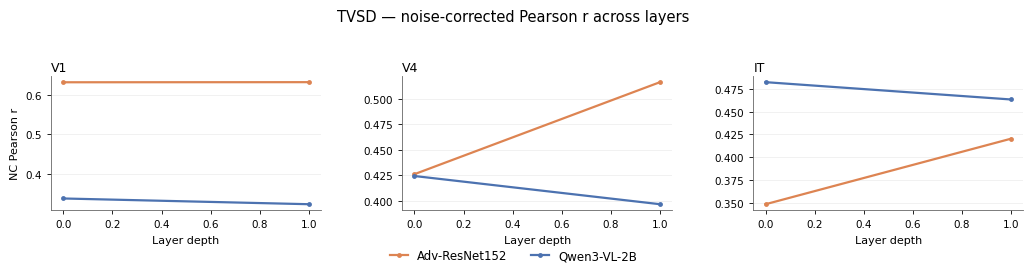

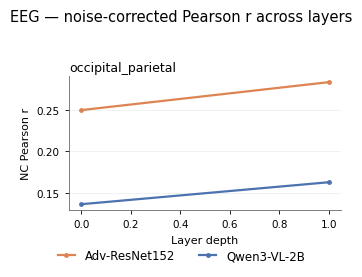

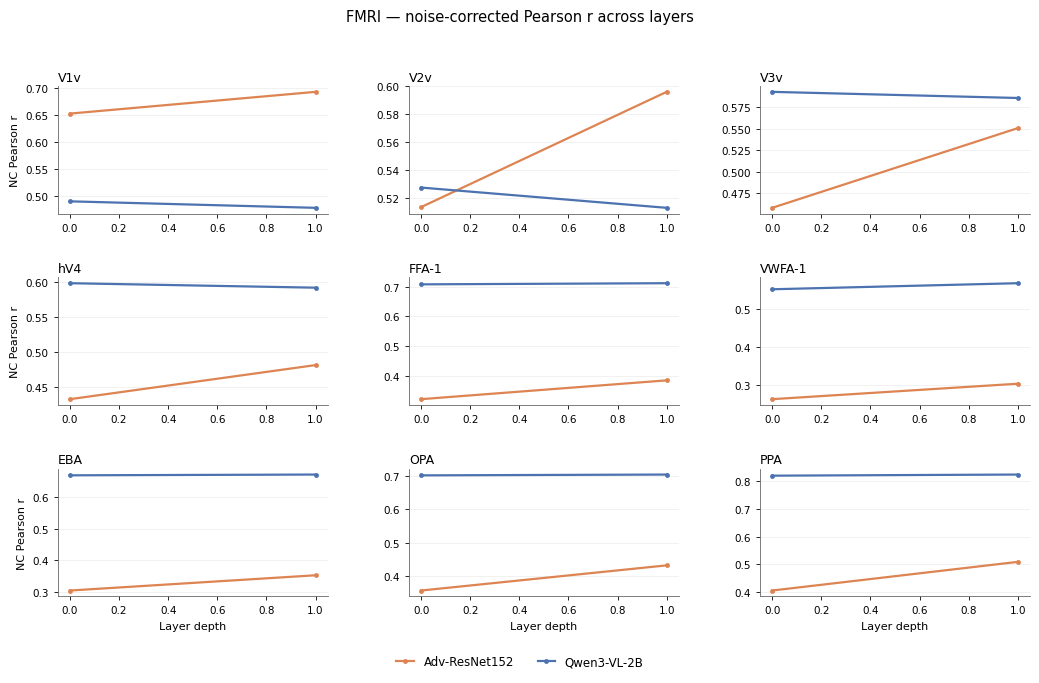

In [89]:
import matplotlib.pyplot as plt

def plot_nc_pearson_for_dataset(df, dataset_name, save_path=None, n_cols=3):
    sub = df[df['dataset'] == dataset_name].copy()
    if sub.empty:
        print(f'No data for {dataset_name}, skipping.')
        return

    def roi_sort_key(roi):
        """Sort ROIs in low- to high-level visual hierarchy order."""
        roi_l = roi.lower()
        # TVSD
        if 'v1' in roi_l: return (0, roi)
        if 'v2' in roi_l: return (1, roi)
        if 'v3' in roi_l: return (2, roi)
        if 'v4' in roi_l or 'hv4' in roi_l: return (3, roi)
        if 'it' in roi_l: return (9, roi)
        # NSD high-level
        if 'ffa'  in roi_l: return (5, roi)
        if 'vwfa' in roi_l: return (6, roi)
        if 'eba'  in roi_l: return (7, roi)
        if 'ppa'  in roi_l: return (8, roi)
        if 'opa'  in roi_l: return (8, roi)
        return (10, roi)  # anything unrecognized goes last
    
    targets = sorted(sub['target'].unique(), key=roi_sort_key)    
    models  = sorted(sub['model'].unique())
    n_targets = len(targets)
    n_cols = min(n_cols, n_targets)
    n_rows = (n_targets + n_cols - 1) // n_cols  # ceil division

    palette = {
        'Qwen3-VL-2B':   '#4C72B0',
        'Adv-ResNet152': '#DD8452',
    }
    fallback = ['#55A868', '#C44E52', '#8172B3']
    for i_m, m in enumerate(models):
        if m not in palette:
            palette[m] = fallback[i_m % len(fallback)]

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.5 * n_cols, 2.0 * n_rows + 0.6),
        squeeze=False, sharex=False,
    )

    for i, target in enumerate(targets):
        row, col = divmod(i, n_cols)
        ax = axes[row, col]

        for model in models:
            d = sub[(sub['target'] == target) & (sub['model'] == model)]
            d = d.sort_values('layer_idx')
            if d.empty:
                continue
            ax.plot(
                d['layer_idx'], d['pearsonr_nc'],
                marker='o', markersize=3.5, linewidth=1.6,
                label=model, color=palette[model],
                markeredgewidth=0,
            )

        y = sub.loc[sub['target'] == target, 'pearsonr_nc']
        y_min, y_max = y.min(), y.max()
        pad = 0.05 * (y_max - y_min) if y_max > y_min else 0.05
        ax.set_ylim(y_min - pad, y_max + pad)

        ax.set_title(target, fontsize=9, loc='left',
                     fontweight='medium', pad=4)
        if col == 0:
            ax.set_ylabel('NC Pearson r', fontsize=8)
        if row == n_rows - 1 or i + n_cols >= n_targets:
            ax.set_xlabel('Layer depth', fontsize=8)
        ax.tick_params(axis='both', labelsize=7.5, length=3, width=0.6)
        ax.grid(axis='y', alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)
        for spine in ('left', 'bottom'):
            ax.spines[spine].set_linewidth(0.6)
            ax.spines[spine].set_color('#666666')

    # Hide any unused subplots in the last row
    for i in range(n_targets, n_rows * n_cols):
        row, col = divmod(i, n_cols)
        axes[row, col].set_visible(False)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='lower center', ncol=len(models),
        bbox_to_anchor=(0.5, -0.02),
        frameon=False, fontsize=8.5,
        handlelength=1.5, columnspacing=2,
    )

    fig.suptitle(
        f'{dataset_name} — noise-corrected Pearson r across layers',
        fontsize=10.5, y=0.995, fontweight='medium',
    )
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])
    fig.subplots_adjust(hspace=0.5, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    return fig


for dataset_name in ['TVSD', 'EEG', 'FMRI']:
    plot_nc_pearson_for_dataset(
        combined, dataset_name,
    )

**Note on layer depth (x-axis).** The x-axis indexes layers in true forward-pass order. The mapping differs between models because their architectures differ:

- **Adv-ResNet152** : depth 0 → `layer1-0`, depth 1 → `layer2-0`, then `layer3-0, 3-5, 3-10, 3-15, 3-20, 3-25, 3-30` (depths 2–8), and depth 9 → `layer4-1`. 
- **Qwen3-VL-2B** : Depths 0–5 correspond to the visual blocks (`visual-blocks-2, -6, -10, -14, -18, -22`) and depths 6–9 correspond to the language-model layers (`language_model-layers-3, -8, -11, -16`). 

![fig_2_4_nc_pearson_TVSD.png](images/fig_2_4_nc_pearson_TVSD.png)
![fig_2_4_nc_pearson_EEG2.png](images/fig_2_4_nc_pearson_EEG2.png)
![fig_2_4_nc_pearson_FMRI.png](images/fig_2_4_nc_pearson_FMRI.png)

### Best layer summary

In [90]:
import pandas as pd

# ============================================================
# Best-layer summary: pick the layer that maximizes pearsonr_nc
# for each (dataset, model, target) combination.
# ============================================================

SELECT_BY = 'pearsonr_nc'

REPORT_COLS = [
    'dataset', 'target', 'model', 'layer',
    'pearsonr', 'pearsonr_nc',
    'explained_variance', 'explained_variance_nc',
    'encoding_rsa', 'encoding_cka',
]

# Index of the row with max selector within each group
idx = combined.groupby(
    ['dataset', 'model', 'target'], observed=True
)[SELECT_BY].idxmax()

best = (
    combined.loc[idx, REPORT_COLS]
    .sort_values(['dataset', 'target', 'model'])
    .reset_index(drop=True)
)

# Round numeric columns for readability
numeric_cols = [
    'pearsonr', 'pearsonr_nc',
    'explained_variance', 'explained_variance_nc',
    'encoding_rsa', 'encoding_cka',
]
best[numeric_cols] = best[numeric_cols].round(3)
best['layer'] = best['layer'].str.replace('features/', '', regex=False)

# Display
print(best.to_string(index=False))

dataset             target         model                    layer  pearsonr  pearsonr_nc  explained_variance  explained_variance_nc  encoding_rsa  encoding_cka
   TVSD                 V1 Adv-ResNet152                 layer2-0     0.616        0.632               0.053                  0.018         0.478         0.750
   TVSD                 V1   Qwen3-VL-2B language_model-layers-11     0.329        0.338               0.030                  0.032         0.082         0.185
   TVSD                 V4 Adv-ResNet152                 layer2-0     0.507        0.516               0.161                  0.161         0.319         0.435
   TVSD                 V4   Qwen3-VL-2B language_model-layers-11     0.416        0.424               0.061                  0.063         0.203         0.328
   TVSD                 IT Adv-ResNet152                 layer2-0     0.406        0.420              -0.020                 -0.041         0.270         0.219
   TVSD                 IT   Qwen3-VL-2B

| dataset | target | model | layer | pearsonr | pearsonr_nc | explained_variance | explained_variance_nc | encoding_rsa | encoding_cka |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| TVSD | V1 | Adv-ResNet152 | layer2-0 | 0.802 | 0.825 | 0.599 | 0.629 | 0.755 | 0.891 |
| TVSD | V1 | Qwen3-VL-2B | visual-blocks-2 | 0.795 | 0.818 | 0.626 | 0.661 | 0.749 | 0.87 |
| TVSD | V4 | Adv-ResNet152 | layer3-5 | 0.763 | 0.778 | 0.569 | 0.588 | 0.671 | 0.807 |
| TVSD | V4 | Qwen3-VL-2B | visual-blocks-6 | 0.743 | 0.757 | 0.542 | 0.561 | 0.628 | 0.783 |
| TVSD | IT | Adv-ResNet152 | layer3-30 | 0.724 | 0.75 | 0.462 | 0.492 | 0.723 | 0.76 |
| TVSD | IT | Qwen3-VL-2B | visual-blocks-6 | 0.691 | 0.716 | 0.459 | 0.49 | 0.675 | 0.676 |
| EEG | occipital_parietal | Adv-ResNet152 | layer3-30 | 0.361 | 0.546 | 0.115 | 0.173 | 0.085 | 0.015 |
| EEG | occipital_parietal | Qwen3-VL-2B | language_model-layers-3 | 0.33 | 0.501 | 0.085 | 0.111 | 0.075 | 0.017 |
| FMRI | V1v | Adv-ResNet152 | layer3-0 | 0.568 | 0.835 | 0.348 | 0.7 | 0.638 | 0.601 |
| FMRI | V1v | Qwen3-VL-2B | visual-blocks-6 | 0.57 | 0.838 | 0.349 | 0.705 | 0.648 | 0.602 |
| FMRI | V2v | Adv-ResNet152 | layer3-0 | 0.515 | 0.791 | 0.294 | 0.628 | 0.582 | 0.59 |
| FMRI | V2v | Qwen3-VL-2B | visual-blocks-6 | 0.527 | 0.81 | 0.306 | 0.659 | 0.613 | 0.608 |
| FMRI | V3v | Adv-ResNet152 | layer3-15 | 0.491 | 0.784 | 0.263 | 0.613 | 0.561 | 0.531 |
| FMRI | V3v | Qwen3-VL-2B | visual-blocks-6 | 0.504 | 0.807 | 0.275 | 0.647 | 0.58 | 0.539 |
| FMRI | hV4 | Adv-ResNet152 | layer3-20 | 0.444 | 0.772 | 0.205 | 0.574 | 0.492 | 0.432 |
| FMRI | hV4 | Qwen3-VL-2B | visual-blocks-6 | 0.444 | 0.769 | 0.214 | 0.588 | 0.508 | 0.452 |
| FMRI | FFA-1 | Adv-ResNet152 | layer4-1 | 0.428 | 0.785 | 0.198 | 0.612 | 0.619 | 0.576 |
| FMRI | FFA-1 | Qwen3-VL-2B | language_model-layers-3 | 0.443 | 0.811 | 0.212 | 0.652 | 0.653 | 0.614 |
| FMRI | VWFA-1 | Adv-ResNet152 | layer4-1 | 0.385 | 0.69 | 0.158 | 0.474 | 0.516 | 0.341 |
| FMRI | VWFA-1 | Qwen3-VL-2B | language_model-layers-3 | 0.405 | 0.724 | 0.173 | 0.519 | 0.544 | 0.372 |
| FMRI | PPA | Adv-ResNet152 | layer4-1 | 0.464 | 0.827 | 0.23 | 0.68 | 0.509 | 0.562 |
| FMRI | PPA | Qwen3-VL-2B | language_model-layers-3 | 0.476 | 0.848 | 0.241 | 0.715 | 0.532 | 0.586 |
| FMRI | OPA | Adv-ResNet152 | layer3-30 | 0.419 | 0.753 | 0.184 | 0.556 | 0.485 | 0.373 |
| FMRI | OPA | Qwen3-VL-2B | language_model-layers-3 | 0.43 | 0.772 | 0.195 | 0.59 | 0.509 | 0.386 |
| FMRI | EBA | Adv-ResNet152 | layer4-1 | 0.489 | 0.771 | 0.259 | 0.589 | 0.699 | 0.658 |
| FMRI | EBA | Qwen3-VL-2B | language_model-layers-3 | 0.513 | 0.809 | 0.281 | 0.644 | 0.736 | 0.701

### **Comparison between the two models using NC-corrected pearson r**


In [91]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# Assumes `best` exists from the best-layer summary step
# (one row per dataset × target × model, with metrics at the
#  layer that maximized pearsonr_nc).
# ============================================================

# Reshape so each (dataset, target) has both models side-by-side
wide = best.pivot_table(
    index=['dataset', 'target'],
    columns='model',
    values=['pearsonr_nc', 'explained_variance_nc'],
).reset_index()

# Flatten the MultiIndex columns
wide.columns = [
    f'{a}__{b}' if b else a
    for a, b in wide.columns
]

# Quick check
print(wide.head())

  dataset              target  explained_variance_nc__Adv-ResNet152  \
0    TVSD                  V1                                 0.018   
1    TVSD                  V4                                 0.161   
2    TVSD                  IT                                -0.041   
3     EEG  occipital_parietal                                -0.105   
4    FMRI                 V1v                                 0.309   

   explained_variance_nc__Qwen3-VL-2B  pearsonr_nc__Adv-ResNet152  \
0                               0.032                       0.632   
1                               0.063                       0.516   
2                               0.063                       0.420   
3                             -12.481                       0.283   
4                               0.009                       0.694   

   pearsonr_nc__Qwen3-VL-2B  
0                     0.338  
1                     0.424  
2                     0.482  
3                     0.163  
4       

/tmp/ipykernel_1622/1324482459.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = best.pivot_table(


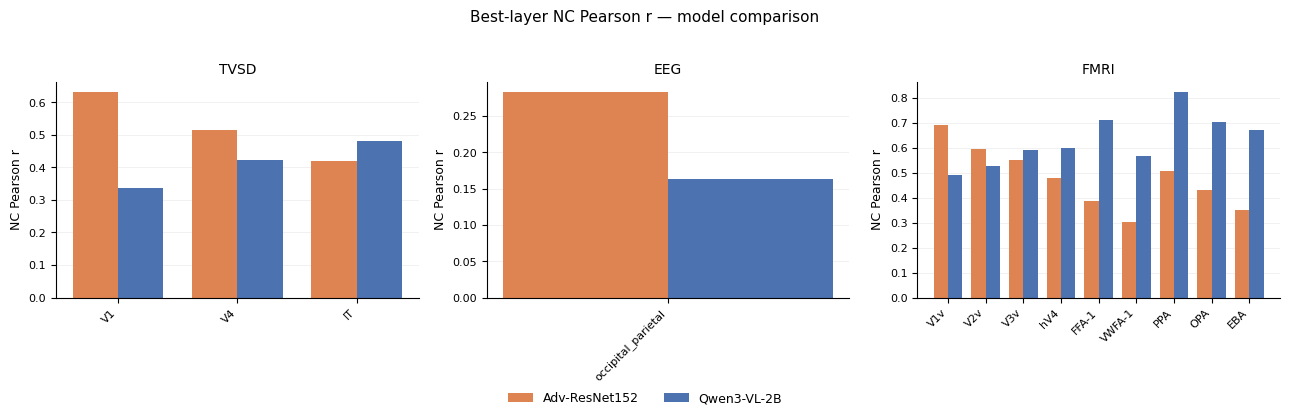

In [92]:
DATASET_ORDER = ['TVSD', 'EEG', 'FMRI']  # match exact strings in wide['dataset']

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), squeeze=False)
for ax, dataset in zip(axes[0], DATASET_ORDER):
    dsub = wide[wide['dataset'] == dataset]
    targets = dsub['target'].values
    x = np.arange(len(targets))
    w = 0.38
    ax.bar(x - w/2, dsub['pearsonr_nc__Adv-ResNet152'], w,
           label='Adv-ResNet152', color='#DD8452')
    ax.bar(x + w/2, dsub['pearsonr_nc__Qwen3-VL-2B'], w,
           label='Qwen3-VL-2B', color='#4C72B0')
    ax.set_xticks(x)
    ax.set_xticklabels(targets, rotation=45, ha='right', fontsize=8)
    ax.set_title(dataset, fontsize=10)
    ax.set_ylabel('NC Pearson r', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
fig.legend(['Adv-ResNet152', 'Qwen3-VL-2B'],
           loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=2, fontsize=9, frameon=False)
fig.suptitle('Best-layer NC Pearson r — model comparison',
             fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

### **Comparison between the two models using NC-corrected pearson r**
![fig_2_4_model_comparison_bars](images/fig_2_4_model_comparison_bars.png)

---

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [93]:
# TODO: compare ranking of layers across metrics
# TODO: identify agreements and disagreements

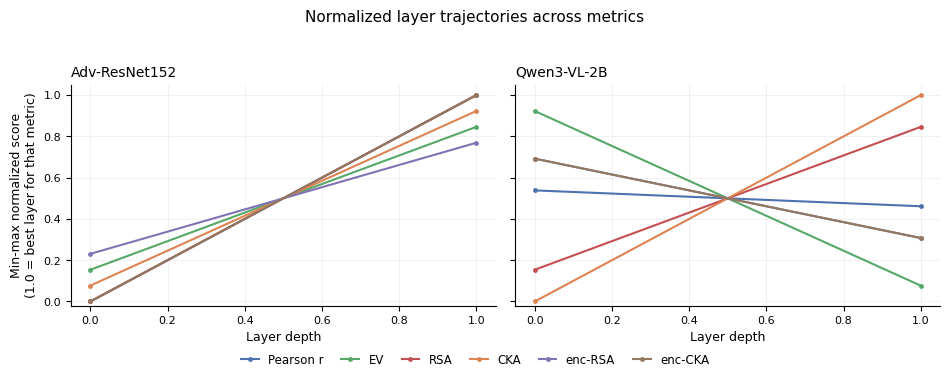

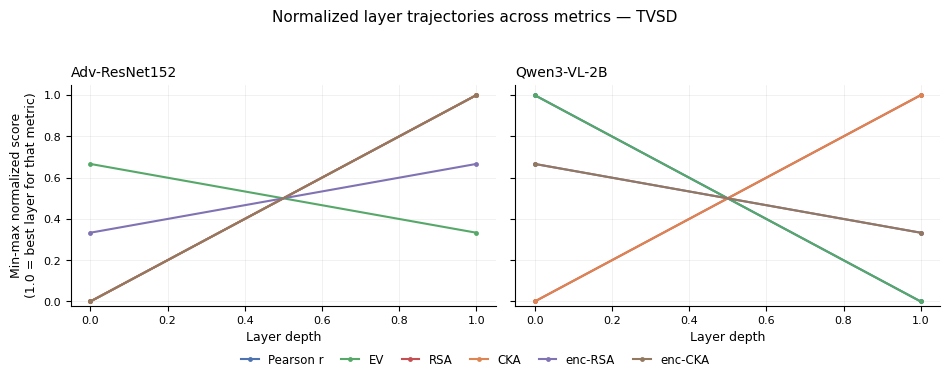

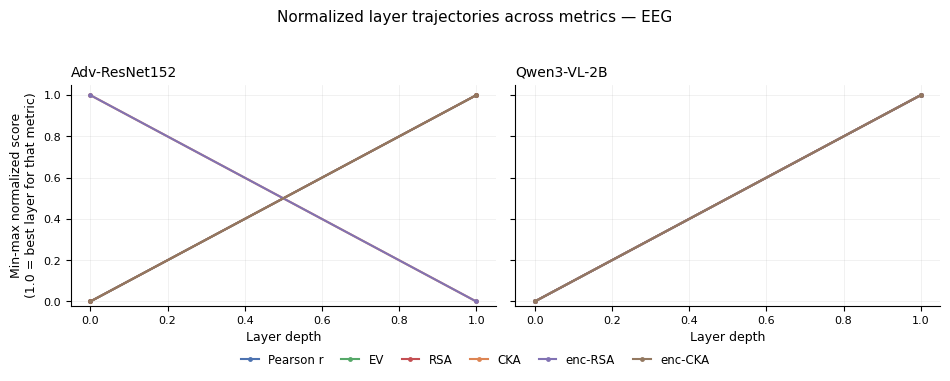

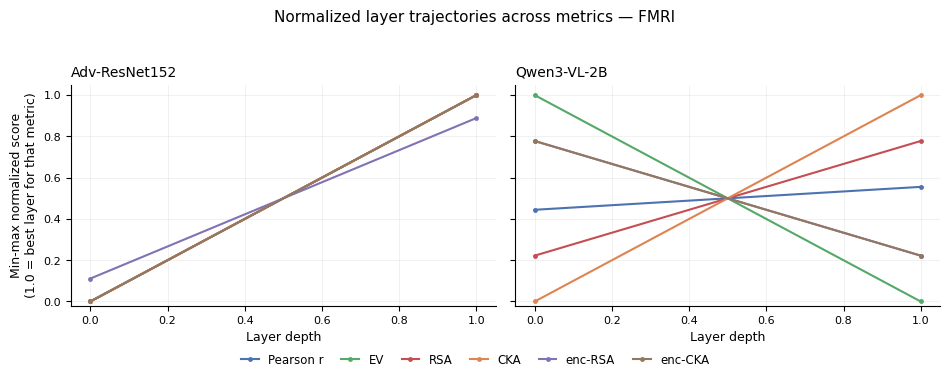

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

METRICS = ['pearsonr', 'explained_variance',
           'rsa', 'cka',
           'encoding_rsa', 'encoding_cka']

METRIC_LABELS = {
    'pearsonr':           'Pearson r',
    'explained_variance': 'EV',
    'rsa':                'RSA',
    'cka':                'CKA',
    'encoding_rsa':       'enc-RSA',
    'encoding_cka':       'enc-CKA',
}

METRIC_COLORS = {
    'pearsonr':           '#4C72B0',
    'explained_variance': '#55A868',
    'rsa':                '#C44E52',
    'cka':                '#DD8452',
    'encoding_rsa':       '#8172B3',
    'encoding_cka':       '#937860',
}


def plot_normalized_trajectories(df, dataset=None, target=None,
                                  models=('Adv-ResNet152', 'Qwen3-VL-2B'),
                                  save_path=None):
    """Side-by-side min-max-normalized trajectory plots, one per model.

    For each metric, scores are normalized to [0, 1] within each
    (dataset, target) group via (s - min) / (max - min). Every metric
    therefore peaks at 1.0, making cross-metric peak alignment readable
    at a glance. When `dataset` / `target` are None, normalized scores
    are averaged across all (dataset, target) groups for a global view.
    """
    sub = df.copy()
    if dataset is not None:
        sub = sub[sub['dataset'] == dataset]
    if target is not None:
        sub = sub[sub['target'] == target]

    fig, axes = plt.subplots(1, len(models),
                             figsize=(4.8 * len(models), 3.6),
                             squeeze=False, sharey=True)

    for ax, model in zip(axes[0], models):
        msub = sub[sub['model'] == model]
        if msub.empty:
            ax.set_visible(False)
            continue

        # Min-max normalize each metric within each (dataset, target) group
        normed = msub.copy()
        for m in METRICS:
            def _minmax(x):
                lo, hi = x.min(), x.max()
                rng = hi - lo
                return (x - lo) / rng if rng > 0 else x * 0.0
            normed[f'{m}_norm'] = (
                normed.groupby(['dataset', 'target'], observed=True)[m]
                      .transform(_minmax)
            )

        # Average normalized scores per layer across (dataset, target) groups
        agg = (normed
               .groupby('layer_idx', observed=True)
               [[f'{m}_norm' for m in METRICS]]
               .mean()
               .sort_index())

        for m in METRICS:
            ax.plot(agg.index, agg[f'{m}_norm'],
                    marker='o', markersize=3.5, linewidth=1.5,
                    color=METRIC_COLORS[m], label=METRIC_LABELS[m],
                    markeredgewidth=0)

        ax.set_xlabel('Layer depth', fontsize=9)
        ax.set_title(model, fontsize=10, loc='left')
        ax.set_ylim(-0.02, 1.05)
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        for spine in ('top', 'right'):
            ax.spines[spine].set_visible(False)

        if 'Qwen' in model:
            qwen_layers = (msub.sort_values('layer_idx')
                              .drop_duplicates('layer_idx')
                              ['layer'].tolist())
            n_visual = sum(1 for l in qwen_layers if 'visual' in l)
            if 0 < n_visual < len(qwen_layers):
                boundary = n_visual - 0.5
                n_total = len(qwen_layers)
                # subtle vertical line
                ax.axvline(boundary, color='gray', linestyle='--',
                           linewidth=0.7, alpha=0.5, zorder=0)
                # pull labels toward the boundary: 0.0 = at center, 1.0 = at boundary
                pull = 0.6
                visual_center  = (boundary - 0.5) / 2
                language_center = (boundary + n_total - 0.5) / 2
                visual_x   = (1 - pull) * visual_center   + pull * boundary
                language_x = (1 - pull) * language_center + pull * boundary
                ax.text(visual_x / (n_total - 1), 1.02, 'visual',
                        transform=ax.transAxes,
                        fontsize=8, color='gray', ha='center', va='bottom')
                ax.text(language_x / (n_total - 1), 1.02, 'language',
                        transform=ax.transAxes,
                        fontsize=8, color='gray', ha='center', va='bottom')
        
            axes[0, 0].set_ylabel('Min-max normalized score\n(1.0 = best layer for that metric)',
                                  fontsize=9)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='lower center', ncol=len(METRICS),
               bbox_to_anchor=(0.5, -0.02),
               frameon=False, fontsize=8.5,
               handlelength=1.5, columnspacing=1.5)

    title = 'Normalized layer trajectories across metrics'
    if dataset:
        title += f' — {dataset}'
    if target:
        title += f' · {target}'
    fig.suptitle(title, fontsize=11, y=1.00)
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])

    plt.show()
    return fig


# --- Global view (averages normalized scores across all dataset × target pairs) ---
plot_normalized_trajectories(combined, save_path='fig_2_5_trajectories_global.png')

# --- Per-dataset views ------------------------------------------------------
for ds in ['TVSD', 'EEG', 'FMRI']:
    plot_normalized_trajectories(combined, dataset=ds,
                                 save_path=f'fig_2_5_trajectories_{ds}.png')

global (averages normalized scores across all dataset × target pairs)
![fig_2_5_trajectories_global](images/fig_2_5_trajectories_global.png)

For each of the 3 datasets
![fig_2_5_trajectories_TVSD](images/fig_2_5_trajectories_TVSD.png)
![fig_2_5_trajectories_EEG](images/fig_2_5_trajectories_EEG.png)
![fig_2_5_trajectories_FMRI](images/fig_2_5_trajectories_FMRI.png)

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [95]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

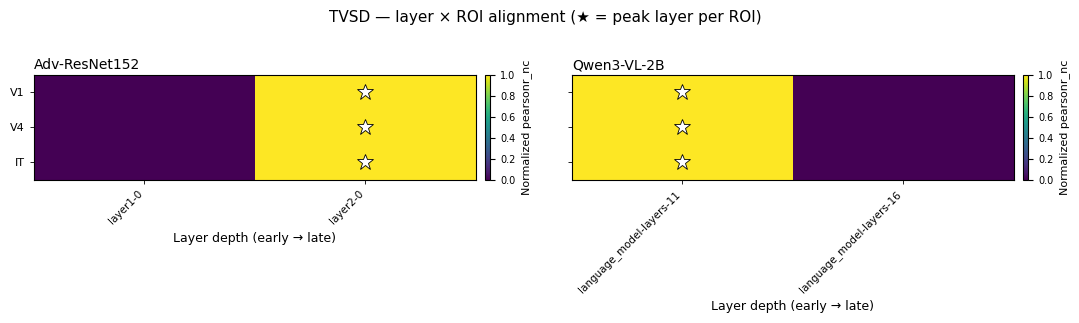

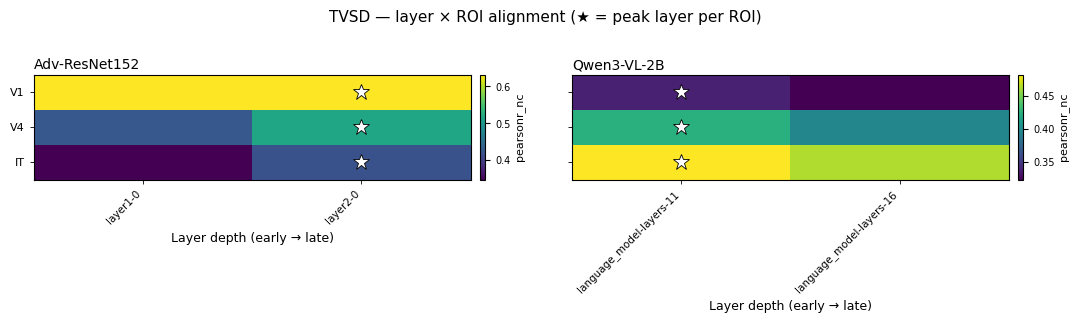

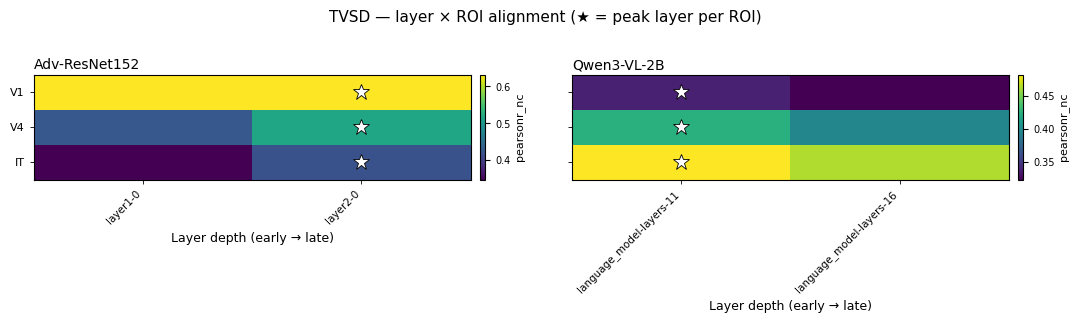

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_tvsd_layer_roi_heatmap(df, metric='pearsonr_nc',
                                 normalize_per_roi=True,
                                 save_path=None):
    """Heatmap of layer × ROI for TVSD, one panel per model.
    
    If normalize_per_roi=True, each row is min-max normalized so the
    peak is at 1.0 — this makes the hierarchical pattern (peak shifts
    rightward as ROI level increases) easy to see across ROIs with
    different absolute score scales.
    """
    sub = df[df['dataset'] == 'TVSD'].copy()
    if sub.empty:
        print('No TVSD data, aborting.'); return

    # Order ROIs by visual hierarchy level (V1 → V4 → IT), monkey grouped
    def roi_key(t):
        roi_l = t.lower()
        if   'v1' in roi_l: lvl = 0
        elif 'v4' in roi_l: lvl = 1
        elif 'it' in roi_l: lvl = 2
        else:               lvl = 3
        monkey = 0 if 'monkeyf' in roi_l else 1
        return (monkey, lvl)
    targets = sorted(sub['target'].unique(), key=roi_key)
    models  = sorted(sub['model'].unique())

    fig, axes = plt.subplots(1, len(models),
                              figsize=(5.5 * len(models), 0.45 * len(targets) + 1.8),
                              squeeze=False, sharey=True)

    for ax, model in zip(axes[0], models):
        msub = sub[sub['model'] == model]

        # Build (target × layer_idx) matrix
        ordered_layers = (msub.sort_values('layer_idx')
                              .drop_duplicates('layer_idx')
                              [['layer_idx', 'layer']])
        layer_order = ordered_layers['layer_idx'].tolist()
        layer_names = [l.split('/')[-1] for l in ordered_layers['layer'].tolist()]

        mat = (msub.pivot_table(index='target', columns='layer_idx',
                                values=metric, observed=True)
                    .reindex(index=targets, columns=layer_order))

        plot_mat = mat.values.astype(float)
        if normalize_per_roi:
            row_min = np.nanmin(plot_mat, axis=1, keepdims=True)
            row_max = np.nanmax(plot_mat, axis=1, keepdims=True)
            rng = row_max - row_min
            rng[rng == 0] = 1.0
            plot_mat = (plot_mat - row_min) / rng

        im = ax.imshow(plot_mat, aspect='auto', cmap='viridis',
                       vmin=0 if normalize_per_roi else None,
                       vmax=1 if normalize_per_roi else None)

        # Mark peak layer per ROI with a white star
        peak_cols = np.nanargmax(mat.values, axis=1)
        for i, j in enumerate(peak_cols):
            ax.plot(j, i, marker='*', color='white', markersize=12,
                    markeredgecolor='black', markeredgewidth=0.6,
                    zorder=5)

        ax.set_xticks(np.arange(len(layer_order)))
        ax.set_xticklabels(layer_names, rotation=45, ha='right', fontsize=7.5)
        ax.set_yticks(np.arange(len(targets)))
        ax.set_yticklabels(targets, fontsize=8)
        ax.set_xlabel('Layer depth (early → late)', fontsize=9)
        ax.set_title(model, fontsize=10, loc='left', pad=4)
        ax.tick_params(length=3, width=0.6)

        # Qwen visual/language boundary marker
        if 'Qwen' in model:
            n_visual = sum(1 for l in ordered_layers['layer'] if 'visual' in l)
            if 0 < n_visual < len(layer_order):
                ax.axvline(n_visual - 0.5, color='white',
                           linestyle='--', linewidth=1.2, alpha=0.8)

        cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        cbar.set_label('Normalized ' + metric if normalize_per_roi
                       else metric, fontsize=8)
        cbar.ax.tick_params(labelsize=7)

    fig.suptitle('TVSD — layer × ROI alignment '
                 '(★ = peak layer per ROI)',
                 fontsize=11, y=1.01, fontweight='medium')
    fig.tight_layout()

    plt.show()
    return fig

plot_tvsd_layer_roi_heatmap(combined, normalize_per_roi=False,
                             save_path='fig_2_6_tvsd_raw.png')
print("")

![fig_2_6_tvsd_raw](images/fig_2_6_tvsd_raw.png)
 

---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

The ResNet model predictions outperform those by Qwen in the EEG and electrophysiology modalities. For fMRI data, the ResNet model makes better aligned predictions in the early visual regions but Qwen outperforms it in regions of higher visual processing. This can be attributed to ResNet's convolutional architecture closely mirroring the retinotopic organization and edge/orientation selectivity of early visual cortex while Qwen's vision-language transformer leverages self-attention mechanisms to integrate global context and semantic information, better capturing the abstract, category-selective representations characteristic of higher-order ventral stream areas.

In [97]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

=== Best-layer scores  (rows=target, columns=metric × model) ===


CKA                   EV (NC)  \
model                      Adv-ResNet152 Qwen3-VL-2B Adv-ResNet152   
dataset target                                                       
EEG     occipital_parietal         0.048       0.050        -0.105   
FMRI    EBA                        0.055       0.001        -0.007   
        FFA-1                      0.056       0.001        -0.008   
        OPA                        0.065       0.001         0.008   
        PPA                        0.059       0.001         0.018   
        V1v                        0.315       0.001         0.309   
        V2v                        0.238       0.001         0.067   
        V3v                        0.184       0.001         0.021   
        VWFA-1                     0.049       0.001        -0.001   
        hV4                        0.166       0.001         0.025   
TVSD    IT                         0.115      -0.003         0.010   
        V1                         0.239      -0.002         0.134   
        V4                         0.122      -0.003         0.161   

                                        Encoding-CKA              \
model                      Qwen3-VL-2B Adv-ResNet152 Qwen3-VL-2B   
dataset target                                                     
EEG     occipital_parietal     -12.481         0.073       0.012   
FMRI    EBA                      0.028         0.102       0.520   
        FFA-1                    0.020         0.079       0.485   
        OPA                      0.035         0.097       0.371   
        PPA                      0.062         0.157       0.521   
        V1v                      0.009         0.496       0.253   
        V2v                      0.008         0.457       0.313   
        V3v                      0.013         0.346       0.328   
        VWFA-1                   0.021         0.057       0.249   
        hV4                      0.012         0.229       0.294   
TVSD    IT                       0.063         0.219       0.386   
        V1                       0.032         0.750       0.185   
        V4                       0.063         0.435       0.389   

                            Encoding-RSA             Pearson r (NC)  \
model                      Adv-ResNet152 Qwen3-VL-2B  Adv-ResNet152   
dataset target                                                        
EEG     occipital_parietal         0.054       0.013          0.283   
FMRI    EBA                        0.116       0.483          0.353   
        FFA-1                      0.079       0.415          0.386   
        OPA                        0.171       0.415          0.433   
        PPA                        0.182       0.407          0.509   
        V1v                        0.554       0.226          0.694   
        V2v                        0.480       0.290          0.596   
        V3v                        0.416       0.315          0.551   
        VWFA-1                     0.081       0.323          0.305   
        hV4                        0.185       0.300          0.481   
TVSD    IT                         0.270       0.364          0.420   
        V1                         0.478       0.082          0.632   
        V4                         0.319       0.279          0.516   

                                                 RSA              
model                      Qwen3-VL-2B Adv-ResNet152 Qwen3-VL-2B  
dataset target                                                    
EEG     occipital_parietal       0.163         0.027       0.018  
FMRI    EBA                      0.671         0.068       0.173  
        FFA-1                    0.711         0.069       0.158  
        OPA                      0.704         0.125       0.189  
        PPA                      0.825         0.112       0.190  
        V1v                      0.490         0.212       0.096  
        V2v                      0.528         0.153       0.118  
        V3v         

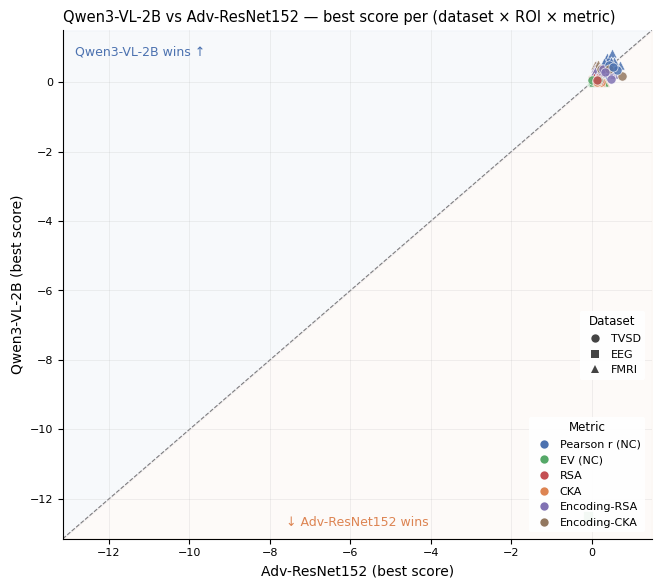

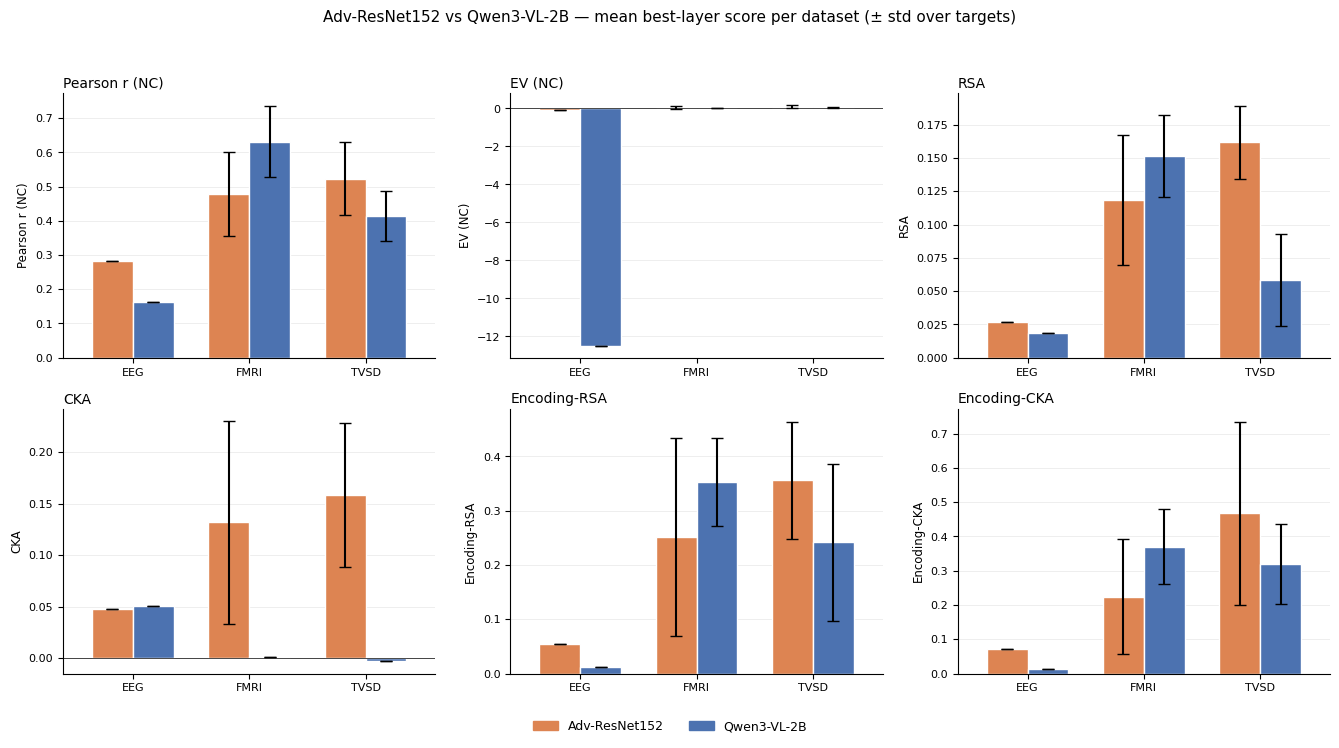

In [98]:
# ─────────────────────────────────────────────────────────────
# CELL 2.7  ·  ResNet vs Qwen3 — overall comparison
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ─── Configuration ───────────────────────────────────────────
METRICS = {
    'Pearson r (NC)': 'pearsonr_nc',
    'EV (NC)':        'explained_variance_nc',
    'RSA':            'rsa',
    'CKA':            'cka',
    'Encoding-RSA':   'encoding_rsa',
    'Encoding-CKA':   'encoding_cka',
}
DATASET_MARKERS = {'TVSD': 'o', 'EEG': 's', 'FMRI': '^'}
METRIC_COLORS = {
    'Pearson r (NC)': '#4C72B0',
    'EV (NC)':        '#55A868',
    'RSA':            '#C44E52',
    'CKA':            '#DD8452',
    'Encoding-RSA':   '#8172B3',
    'Encoding-CKA':   '#937860',
}
MODEL_COLORS = {'Adv-ResNet152': '#DD8452', 'Qwen3-VL-2B': '#4C72B0'}
MODEL_A, MODEL_B = 'Adv-ResNet152', 'Qwen3-VL-2B'

short_layer_name = lambda s: s.split('/')[-1] if isinstance(s, str) else s
models = sorted(combined['model'].unique())

# Drop metrics that don't exist in `combined`
METRICS = {name: col for name, col in METRICS.items() if col in combined.columns}
metric_names = list(METRICS.keys())


# ─────────────────────────────────────────────────────────────
# 1) For each (dataset, model, target), find the best score
#    and best layer for each metric
# ─────────────────────────────────────────────────────────────
records = []
for keys, grp in combined.groupby(['dataset', 'model', 'target'], observed=True):
    record = dict(zip(['dataset', 'model', 'target'], keys))
    for metric_name, metric_col in METRICS.items():
        if grp[metric_col].notna().any():
            best_row_idx = grp[metric_col].idxmax()
            record[metric_name]            = grp.at[best_row_idx, metric_col]
            record[f'{metric_name}_layer'] = short_layer_name(grp.at[best_row_idx, 'layer'])
        else:
            record[metric_name]            = np.nan
            record[f'{metric_name}_layer'] = None
    records.append(record)
best_per_target = pd.DataFrame(records)


# ─────────────────────────────────────────────────────────────
# 2) Side-by-side summary table
# ─────────────────────────────────────────────────────────────
summary_table = (best_per_target
                 .pivot_table(index=['dataset', 'target'],
                              columns='model', values=metric_names,
                              observed=True)
                 .round(3))
print('=== Best-layer scores  (rows=target, columns=metric × model) ===')
display(summary_table)

# ─────────────────────────────────────────────────────────────
# 3a) Summary figure — SCATTER
# ─────────────────────────────────────────────────────────────
# One row per (dataset, target, metric), columns = each model's score
model_pairs = best_per_target.melt(
    id_vars=['dataset', 'model', 'target'],
    value_vars=metric_names,
    var_name='metric', value_name='score',
)
model_pairs = (model_pairs
               .pivot_table(index=['dataset', 'target', 'metric'],
                            columns='model', values='score',
                            aggfunc='first', observed=True)
               .reset_index()
               .dropna(subset=models))

fig, ax = plt.subplots(figsize=(9.5, 6.2))
all_scores = pd.concat([model_pairs[MODEL_A], model_pairs[MODEL_B]]).dropna()
score_min, score_max = float(all_scores.min()), float(all_scores.max())
pad = 0.05 * (score_max - score_min)

ax.plot([score_min - pad, score_max + pad], [score_min - pad, score_max + pad],
        color='gray', linestyle='--', linewidth=0.8, zorder=0)
ax.fill_between([score_min - pad, score_max + pad],
                 [score_min - pad, score_max + pad], [score_max + pad] * 2,
                 color='#4C72B0', alpha=0.04, zorder=0)
ax.fill_between([score_min - pad, score_max + pad],
                 [score_min - pad, score_min - pad],
                 [score_min - pad, score_max + pad],
                 color='#DD8452', alpha=0.04, zorder=0)

for _, row in model_pairs.iterrows():
    ax.scatter(row[MODEL_A], row[MODEL_B],
               color=METRIC_COLORS[row['metric']],
               marker=DATASET_MARKERS.get(row['dataset'], 'o'),
               s=44, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xlim(score_min - pad, score_max + pad)
ax.set_ylim(score_min - pad, score_max + pad)
ax.set_xlabel(f'{MODEL_A} (best score)', fontsize=10)
ax.set_ylabel(f'{MODEL_B} (best score)', fontsize=10)
ax.set_title(f'{MODEL_B} vs {MODEL_A} — best score per (dataset × ROI × metric)',
             fontsize=10.5, loc='left', pad=6, fontweight='medium')
ax.tick_params(labelsize=8)
ax.grid(alpha=0.25, linewidth=0.5)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

ax.text(0.02, 0.97, f'{MODEL_B} wins ↑', transform=ax.transAxes,
        fontsize=9, color='#4C72B0', ha='left', va='top', fontweight='medium')
ax.text(0.50, 0.02, f'↓ {MODEL_A} wins', transform=ax.transAxes,
        fontsize=9, color='#DD8452', ha='center', va='bottom', fontweight='medium')
metric_legend_handles = [
    Line2D([], [], marker='o', linestyle='',
           color=METRIC_COLORS[m], markersize=6,
           markeredgewidth=0, label=m)
    for m in METRICS
]
dataset_legend_handles = [
    Line2D([], [], marker=DATASET_MARKERS[d], linestyle='',
           color='#444', markersize=6, markeredgewidth=0, label=d)
    for d in DATASET_MARKERS if d in model_pairs['dataset'].unique()
]
metric_legend = ax.legend(handles=metric_legend_handles, title='Metric',
                           loc='lower right',
                           fontsize=8, title_fontsize=8.5, frameon=True,
                           facecolor='white', edgecolor='none',
                           framealpha=0.92,
                           handletextpad=0.4, borderaxespad=0.6)
ax.add_artist(metric_legend)
ax.legend(handles=dataset_legend_handles, title='Dataset',
          loc='lower right', bbox_to_anchor=(1.0, 0.30),
          fontsize=8, title_fontsize=8.5, frameon=True,
          facecolor='white', edgecolor='none',
          framealpha=0.92,
          handletextpad=0.4, borderaxespad=0.6)

fig.subplots_adjust(left=0.10, right=0.72, top=0.92, bottom=0.10)
plt.show()


# ─────────────────────────────────────────────────────────────
# 3b) Summary figure — BAR GRID (one panel per metric)
# ─────────────────────────────────────────────────────────────
n_metrics = len(METRICS)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.6 * n_rows),
                          squeeze=False)

for ax, metric_name in zip(axes.flat, METRICS):
    dataset_stats = (best_per_target
                     .groupby(['dataset', 'model'], observed=True)[metric_name]
                     .agg(['mean', 'std'])
                     .reset_index())
    mean_per_dataset = dataset_stats.pivot(index='dataset', columns='model', values='mean')
    std_per_dataset  = dataset_stats.pivot(index='dataset', columns='model', values='std').fillna(0)

    # Order columns explicitly so colors are stable
    ordered_models = [m for m in models if m in mean_per_dataset.columns]
    mean_per_dataset = mean_per_dataset[ordered_models]
    std_per_dataset  = std_per_dataset[ordered_models]
    bar_colors       = [MODEL_COLORS.get(m, '#888') for m in ordered_models]

    mean_per_dataset.plot(kind='bar', ax=ax, yerr=std_per_dataset,
                           color=bar_colors, width=0.7,
                           edgecolor='white', capsize=4, legend=False)
    ax.set_title(metric_name, fontsize=10, loc='left', fontweight='medium', pad=4)
    ax.set_xlabel('')
    ax.set_ylabel(metric_name, fontsize=8.5)
    ax.tick_params(axis='x', rotation=0, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.axhline(0, color='black', lw=0.5)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

# Hide unused axes
for ax in axes.flat[n_metrics:]:
    ax.set_visible(False)

# Single figure-level legend
model_legend_handles = [plt.Rectangle((0, 0), 1, 1, color=MODEL_COLORS.get(m, '#888'))
                         for m in models]
fig.legend(model_legend_handles, models, loc='lower center', ncol=len(models),
           bbox_to_anchor=(0.5, -0.02),
           fontsize=9, frameon=False)

fig.suptitle(f'{MODEL_A} vs {MODEL_B} — mean best-layer score per dataset (± std over targets)',
             fontsize=11, y=1.00, fontweight='medium')
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

### Per-metric peak scores across layers
Each cell shows the highest value of that metric across all layers of the model.



| dataset | target | CKA · Adv-ResNet152 | CKA · Qwen3-VL-2B | EV (NC) · Adv-ResNet152 | EV (NC) · Qwen3-VL-2B | Encoding-CKA · Adv-ResNet152 | Encoding-CKA · Qwen3-VL-2B | Encoding-RSA · Adv-ResNet152 | Encoding-RSA · Qwen3-VL-2B | Pearson r (NC) · Adv-ResNet152 | Pearson r (NC) · Qwen3-VL-2B | RSA · Adv-ResNet152 | RSA · Qwen3-VL-2B |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| EEG | occipital_parietal | 0.009 | 0.007 | 0.173 | 0.114 | 0.018 | 0.017 | 0.085 | 0.075 | 0.546 | 0.501 | 0.03 | 0.018 |
| FMRI | EBA | 0.245 | 0.226 | 0.589 | 0.644 | 0.658 | 0.703 | 0.699 | 0.743 | 0.771 | 0.809 | 0.24 | 0.175 |
| FMRI | FFA-1 | 0.188 | 0.185 | 0.612 | 0.652 | 0.576 | 0.614 | 0.619 | 0.653 | 0.785 | 0.811 | 0.211 | 0.158 |
| FMRI | OPA | 0.187 | 0.179 | 0.557 | 0.59 | 0.373 | 0.386 | 0.485 | 0.514 | 0.753 | 0.772 | 0.274 | 0.189 |
| FMRI | PPA | 0.247 | 0.231 | 0.68 | 0.715 | 0.562 | 0.586 | 0.509 | 0.537 | 0.827 | 0.848 | 0.289 | 0.19 |
| FMRI | V1v | 0.35 | 0.275 | 0.7 | 0.705 | 0.601 | 0.602 | 0.638 | 0.648 | 0.835 | 0.838 | 0.273 | 0.217 |
| FMRI | V2v | 0.291 | 0.18 | 0.628 | 0.659 | 0.598 | 0.608 | 0.594 | 0.613 | 0.791 | 0.81 | 0.228 | 0.139 |
| FMRI | V3v | 0.237 | 0.188 | 0.613 | 0.647 | 0.532 | 0.539 | 0.565 | 0.581 | 0.784 | 0.807 | 0.201 | 0.15 |
| FMRI | VWFA-1 | 0.156 | 0.141 | 0.474 | 0.519 | 0.341 | 0.372 | 0.516 | 0.553 | 0.69 | 0.724 | 0.199 | 0.146 |
| FMRI | hV4 | 0.209 | 0.191 | 0.578 | 0.588 | 0.448 | 0.457 | 0.51 | 0.529 | 0.772 | 0.769 | 0.196 | 0.153 |
| TVSD | IT | 0.301 | 0.167 | 0.495 | 0.49 | 0.76 | 0.676 | 0.723 | 0.675 | 0.75 | 0.716 | 0.29 | 0.113 |
| TVSD | V1 | 0.347 | 0.179 | 0.629 | 0.661 | 0.891 | 0.87 | 0.755 | 0.749 | 0.825 | 0.818 | 0.198 | 0.13 |
| TVSD | V4 | 0.258 | 0.098 | 0.588 | 0.561 | 0.817 | 0.783 | 0.684 | 0.628 | 0.778 | 0.757 | 0.213 | 0.068 |

![fig_2_7_scatter](images/fig_2_7_scatter.png)
![fig_2_7_bar_grid](images/fig_2_7_bar_grid.png)


---

# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

MY IDEA: Compare layers to EEG readouts at diff times - good result if max match at typical V1 processing time, V2 etc.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

3. **Method**  
   What did you change relative to the linear baseline?

4. **Comparison**  
   How does it compare to the baseline?

5. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [ ]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

---

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.